# Normlaztion of Death Times

In [1]:
import os
import sys
import shutil
import math
import warnings
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import *
from enum import Enum
from scipy.spatial import Voronoi
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import LabelEncoder
from scipy.stats import wasserstein_distance
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.utils import get_experiment_cell_death_times_by_specific_siliding_window,read_experiment_cell_xy_and_death_times
from src.NucleationAndPropagationMeasurements import replace_ugly_long_name
from src.quanta_utils import get_neighbors
from src.DeathQuanta import DeathQuanta

In [2]:
csv_path = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/field13_crop-001_ROI#1_annotation_nec.csv'
# csv_path = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_live_only/purecolony1.csv'
df_csv = pd.read_csv(csv_path)

## Seperate plot for each death mode

Processing file: 3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath3_sytox_based.csv


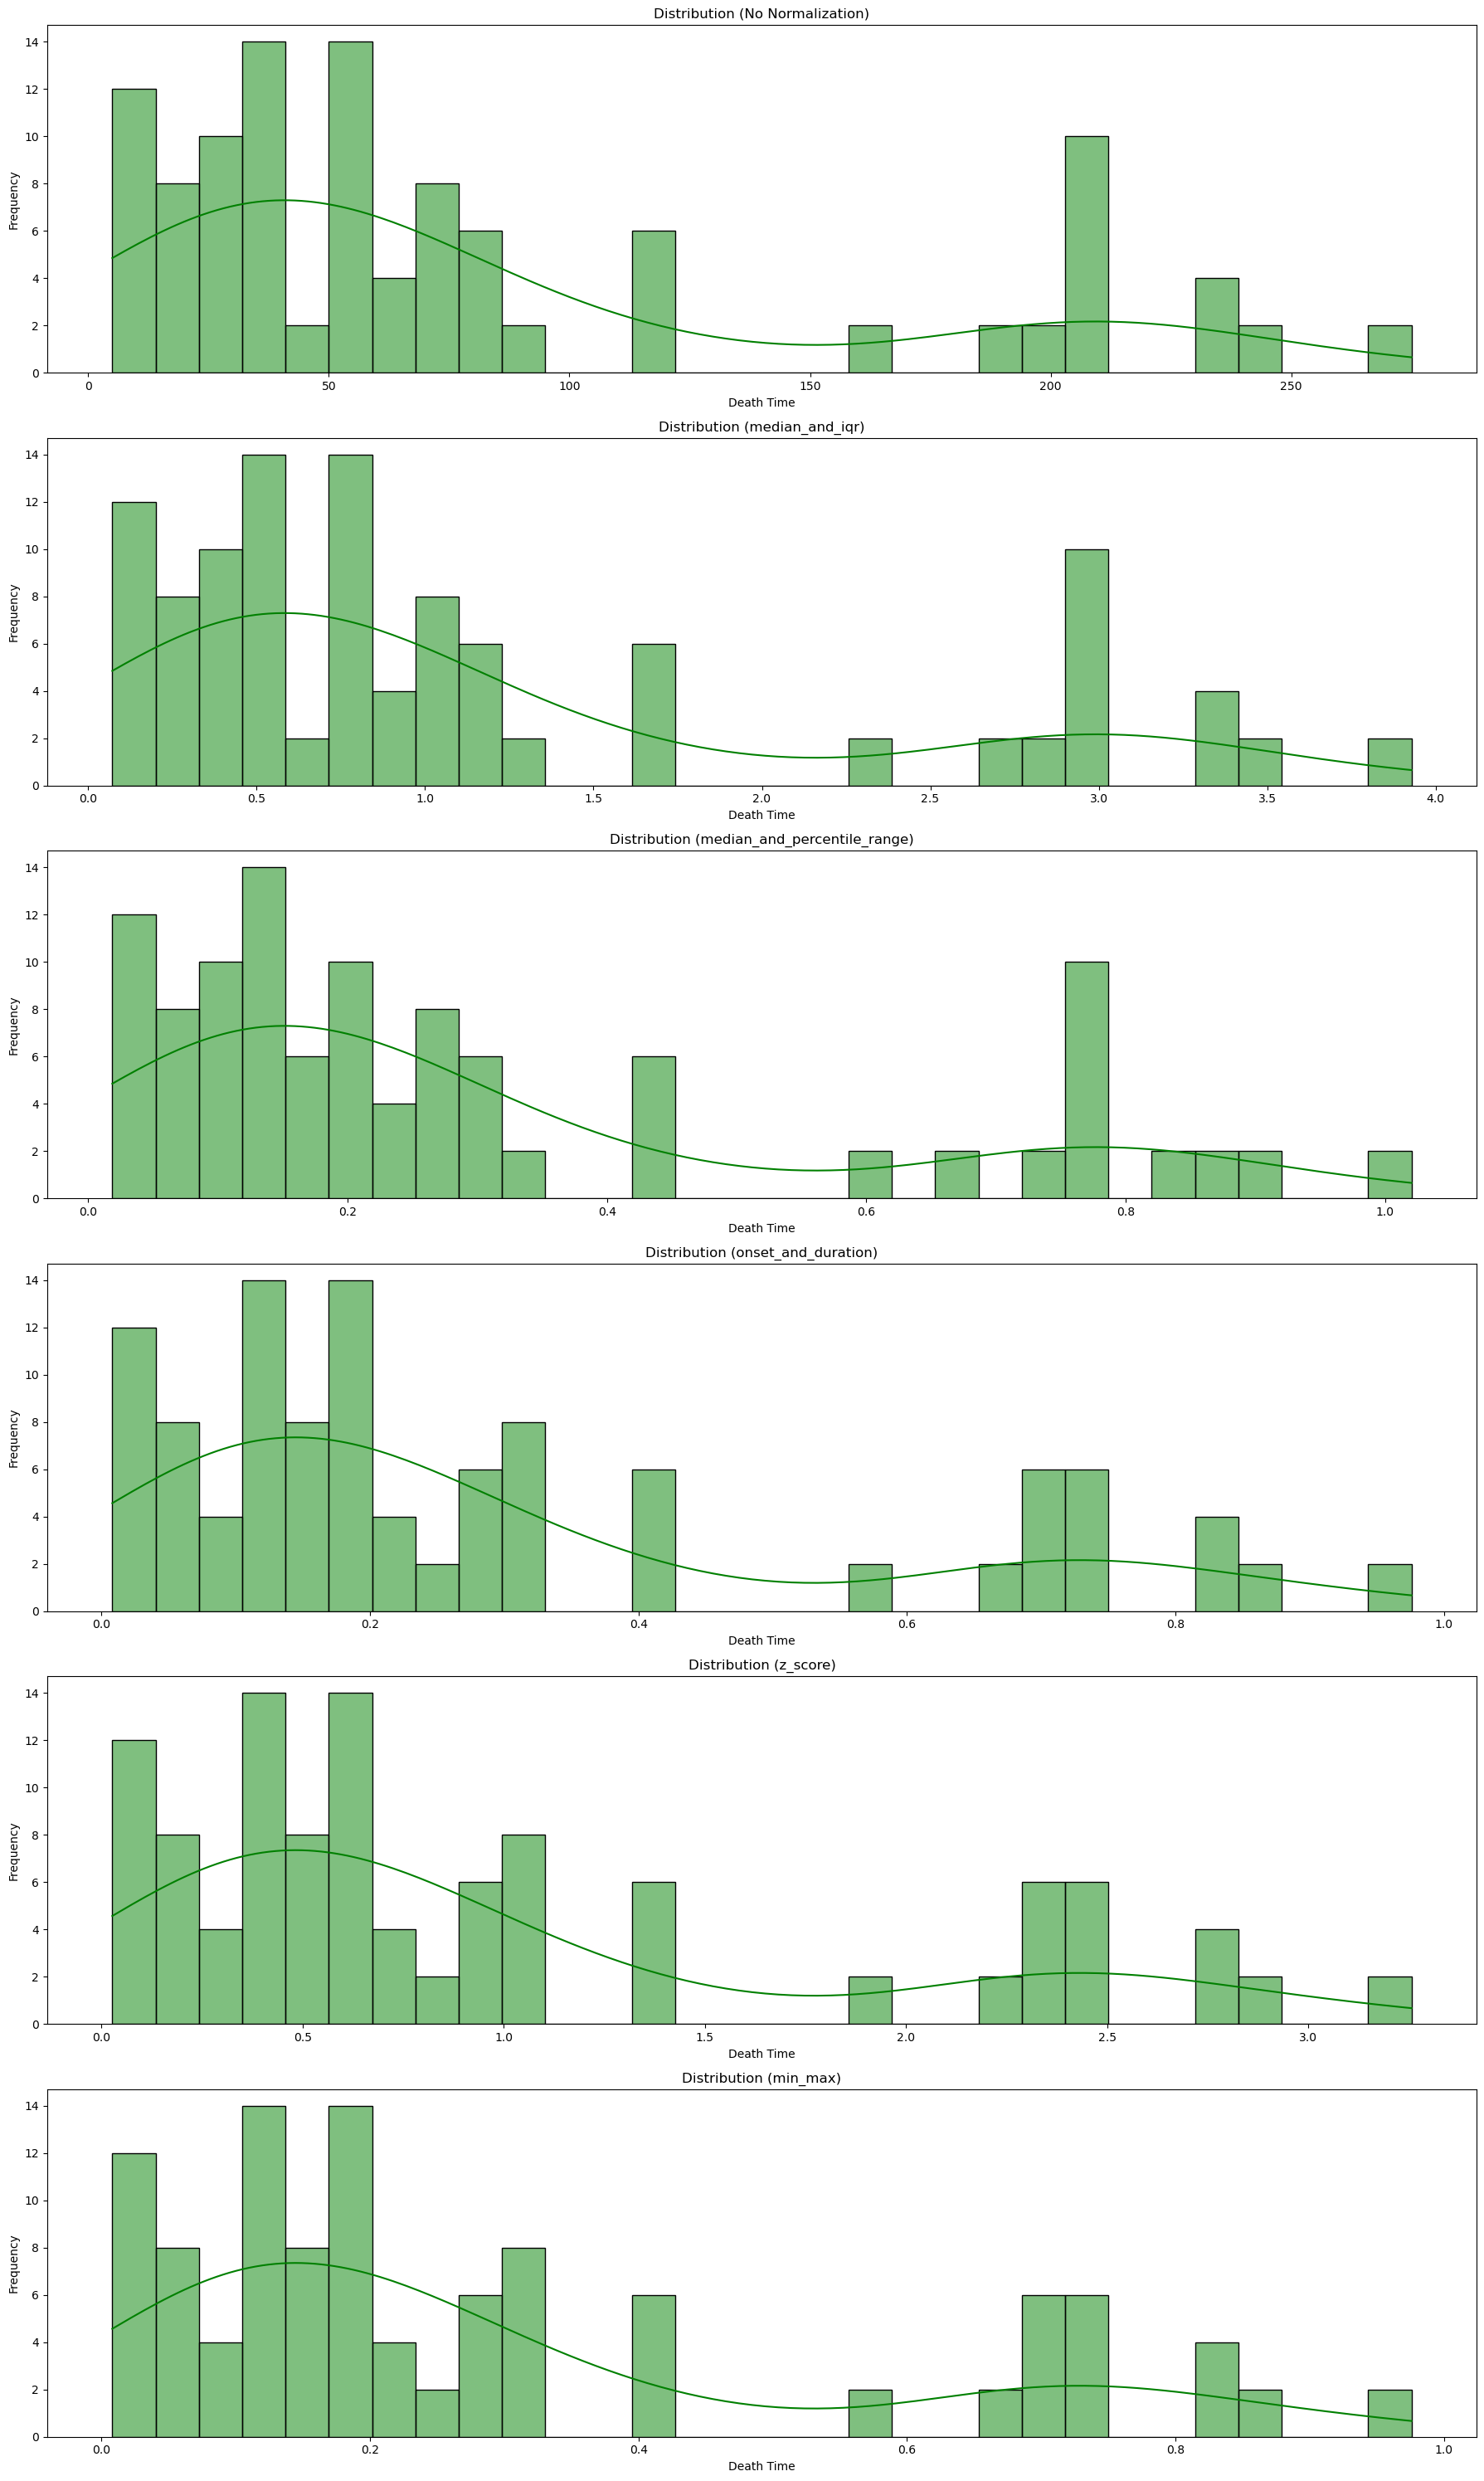

Processing file: 3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath1_sytox_based.csv


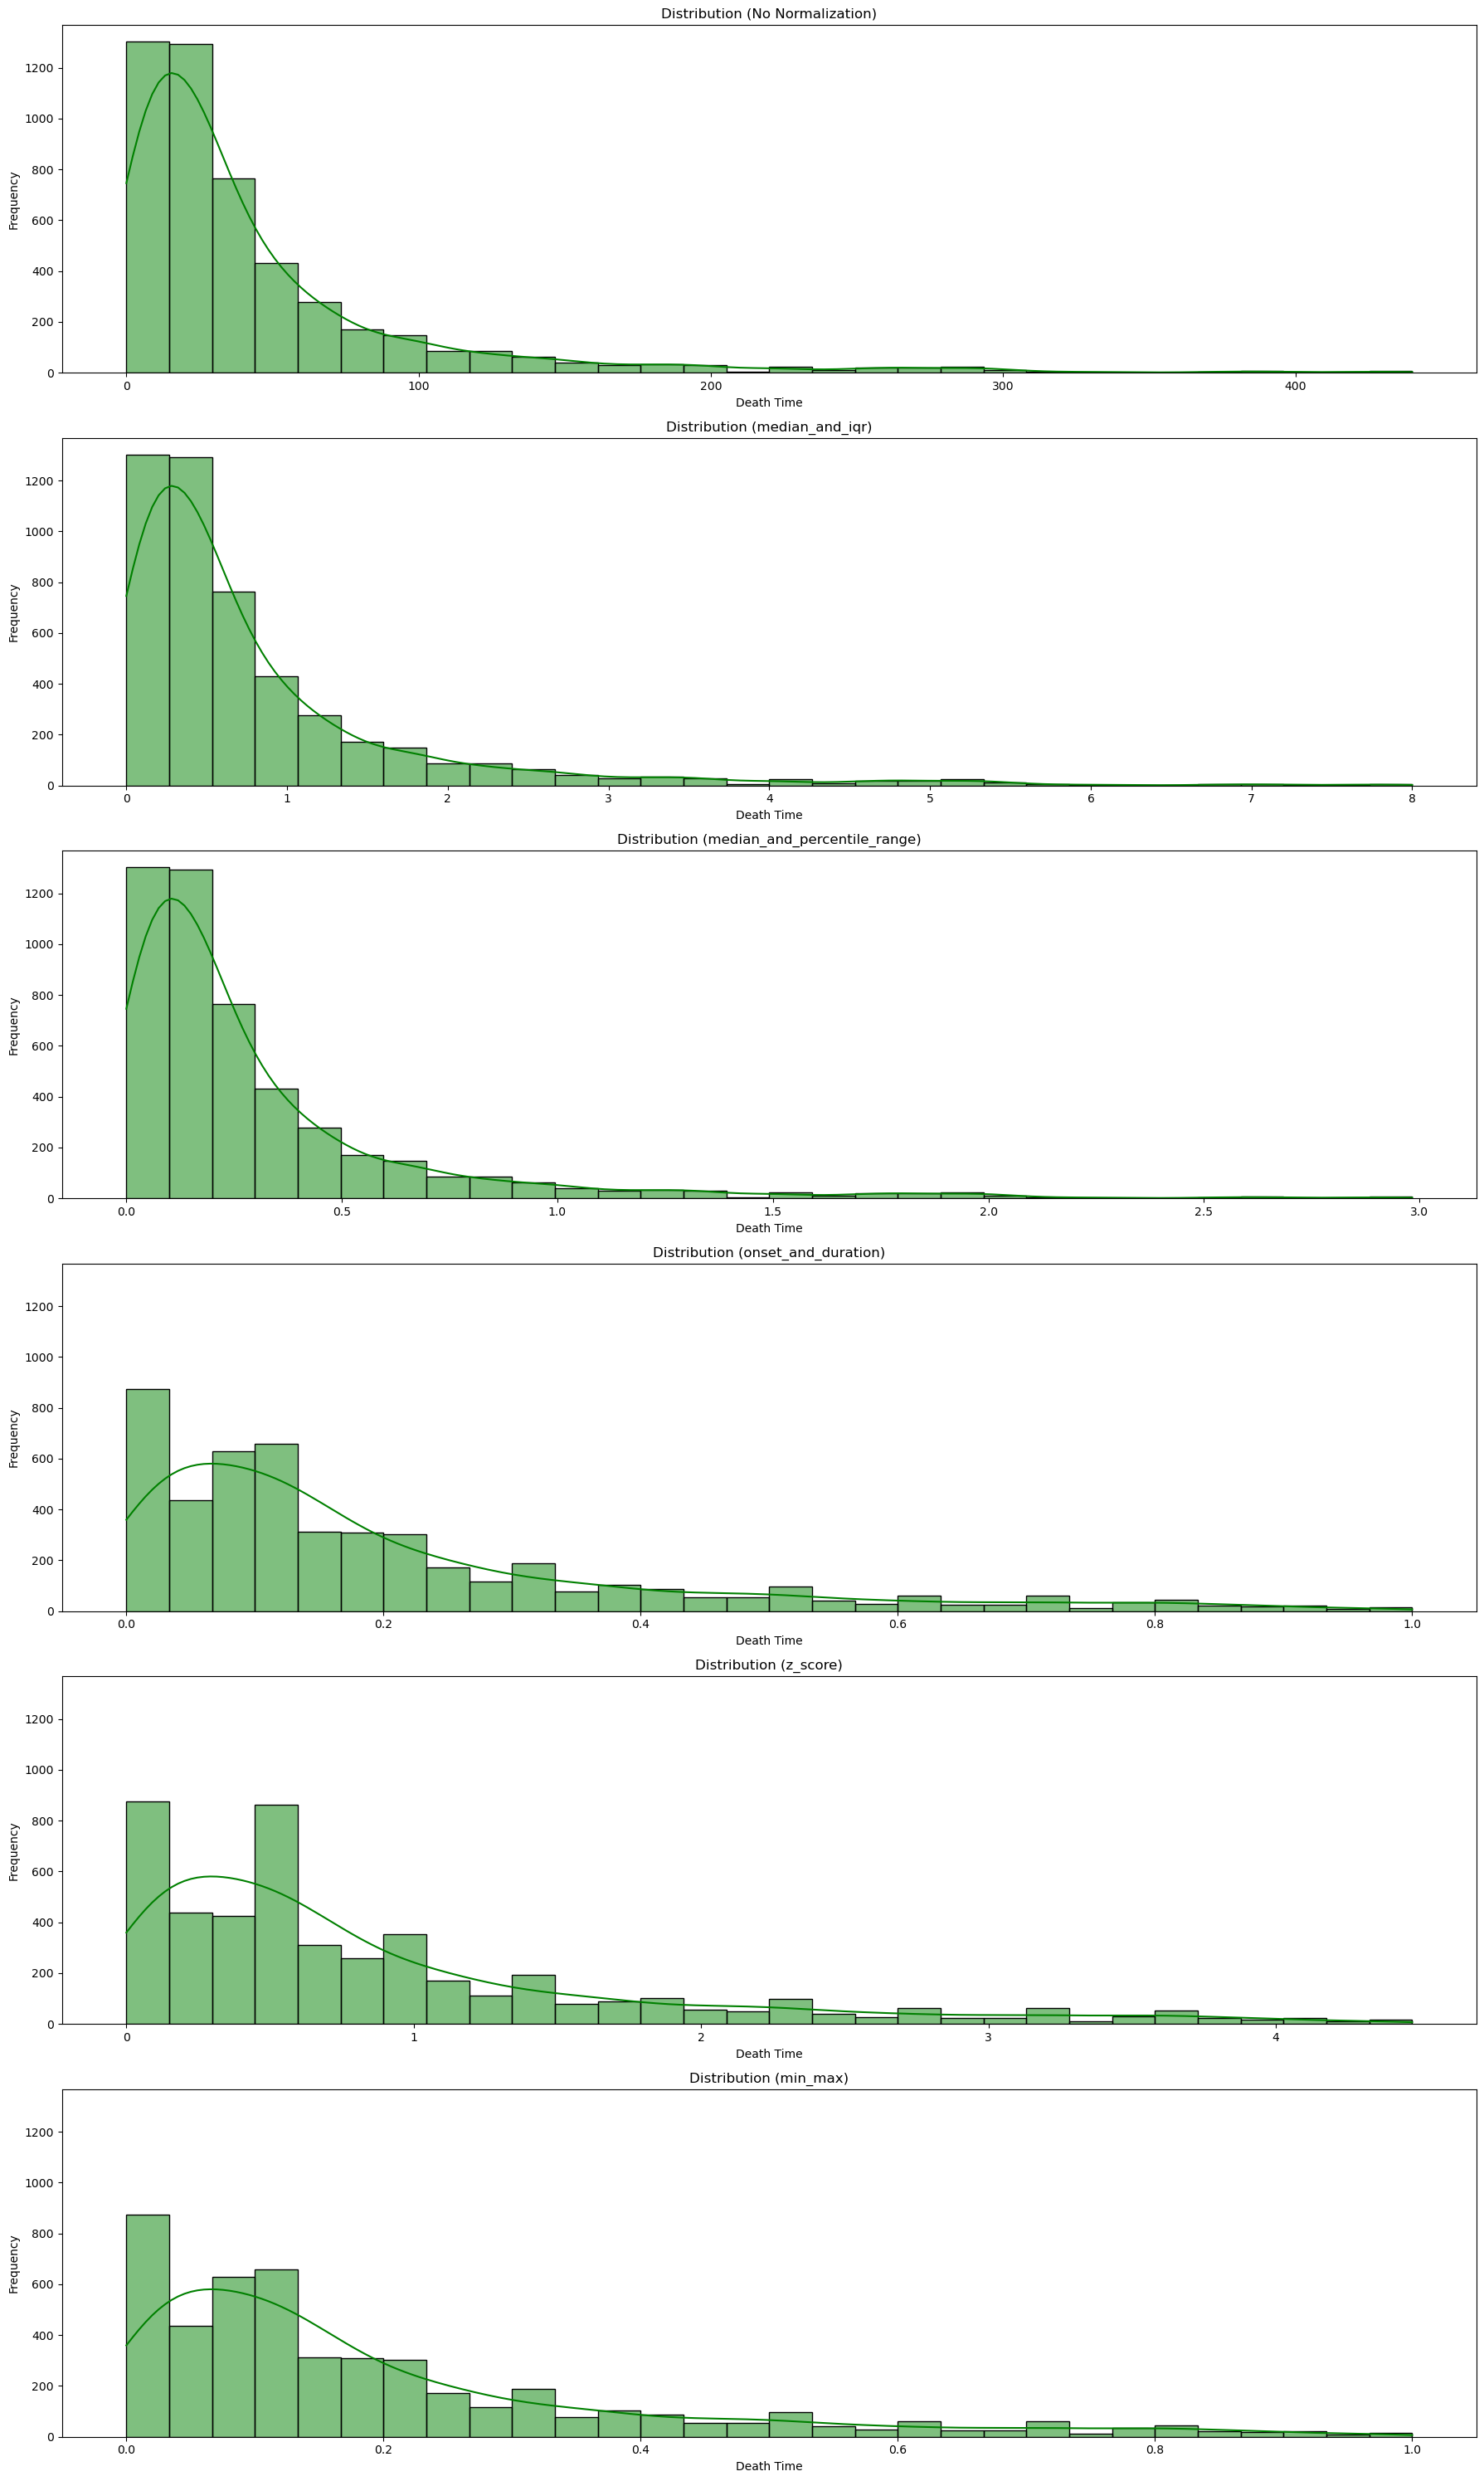

Processing file: purecolony_sytox_based.csv


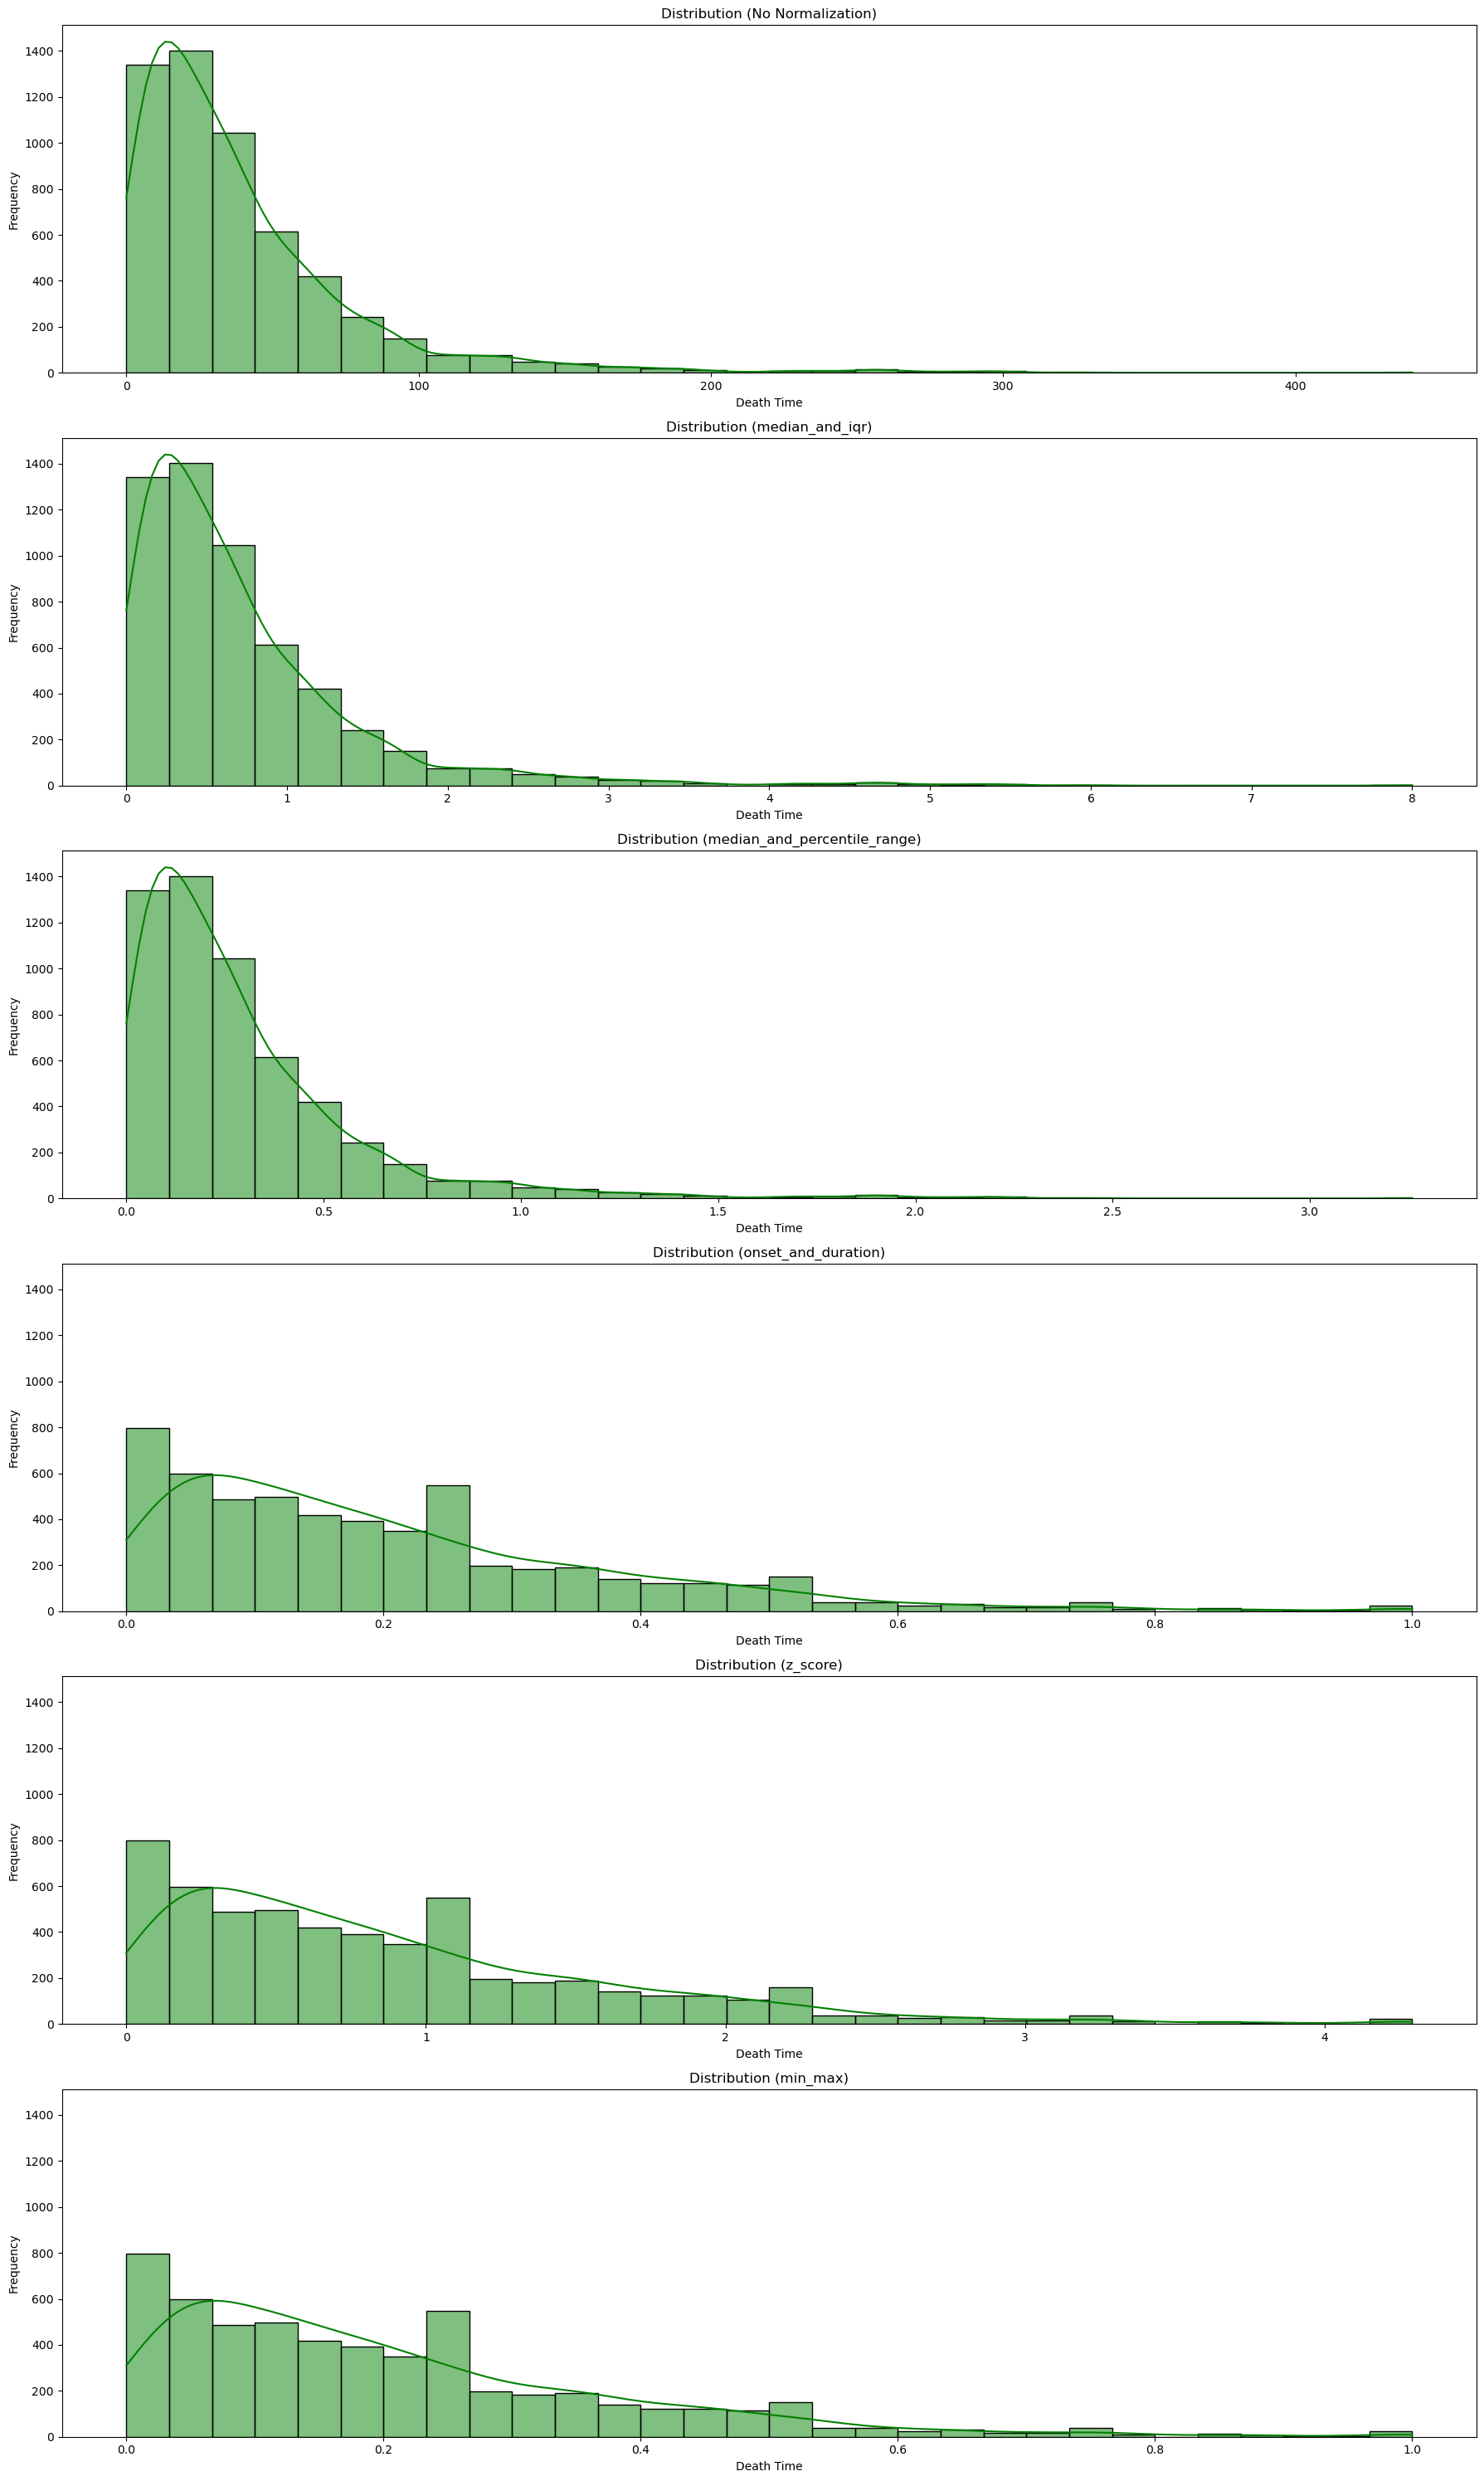

Processing file: 3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath2_sytox_based.csv


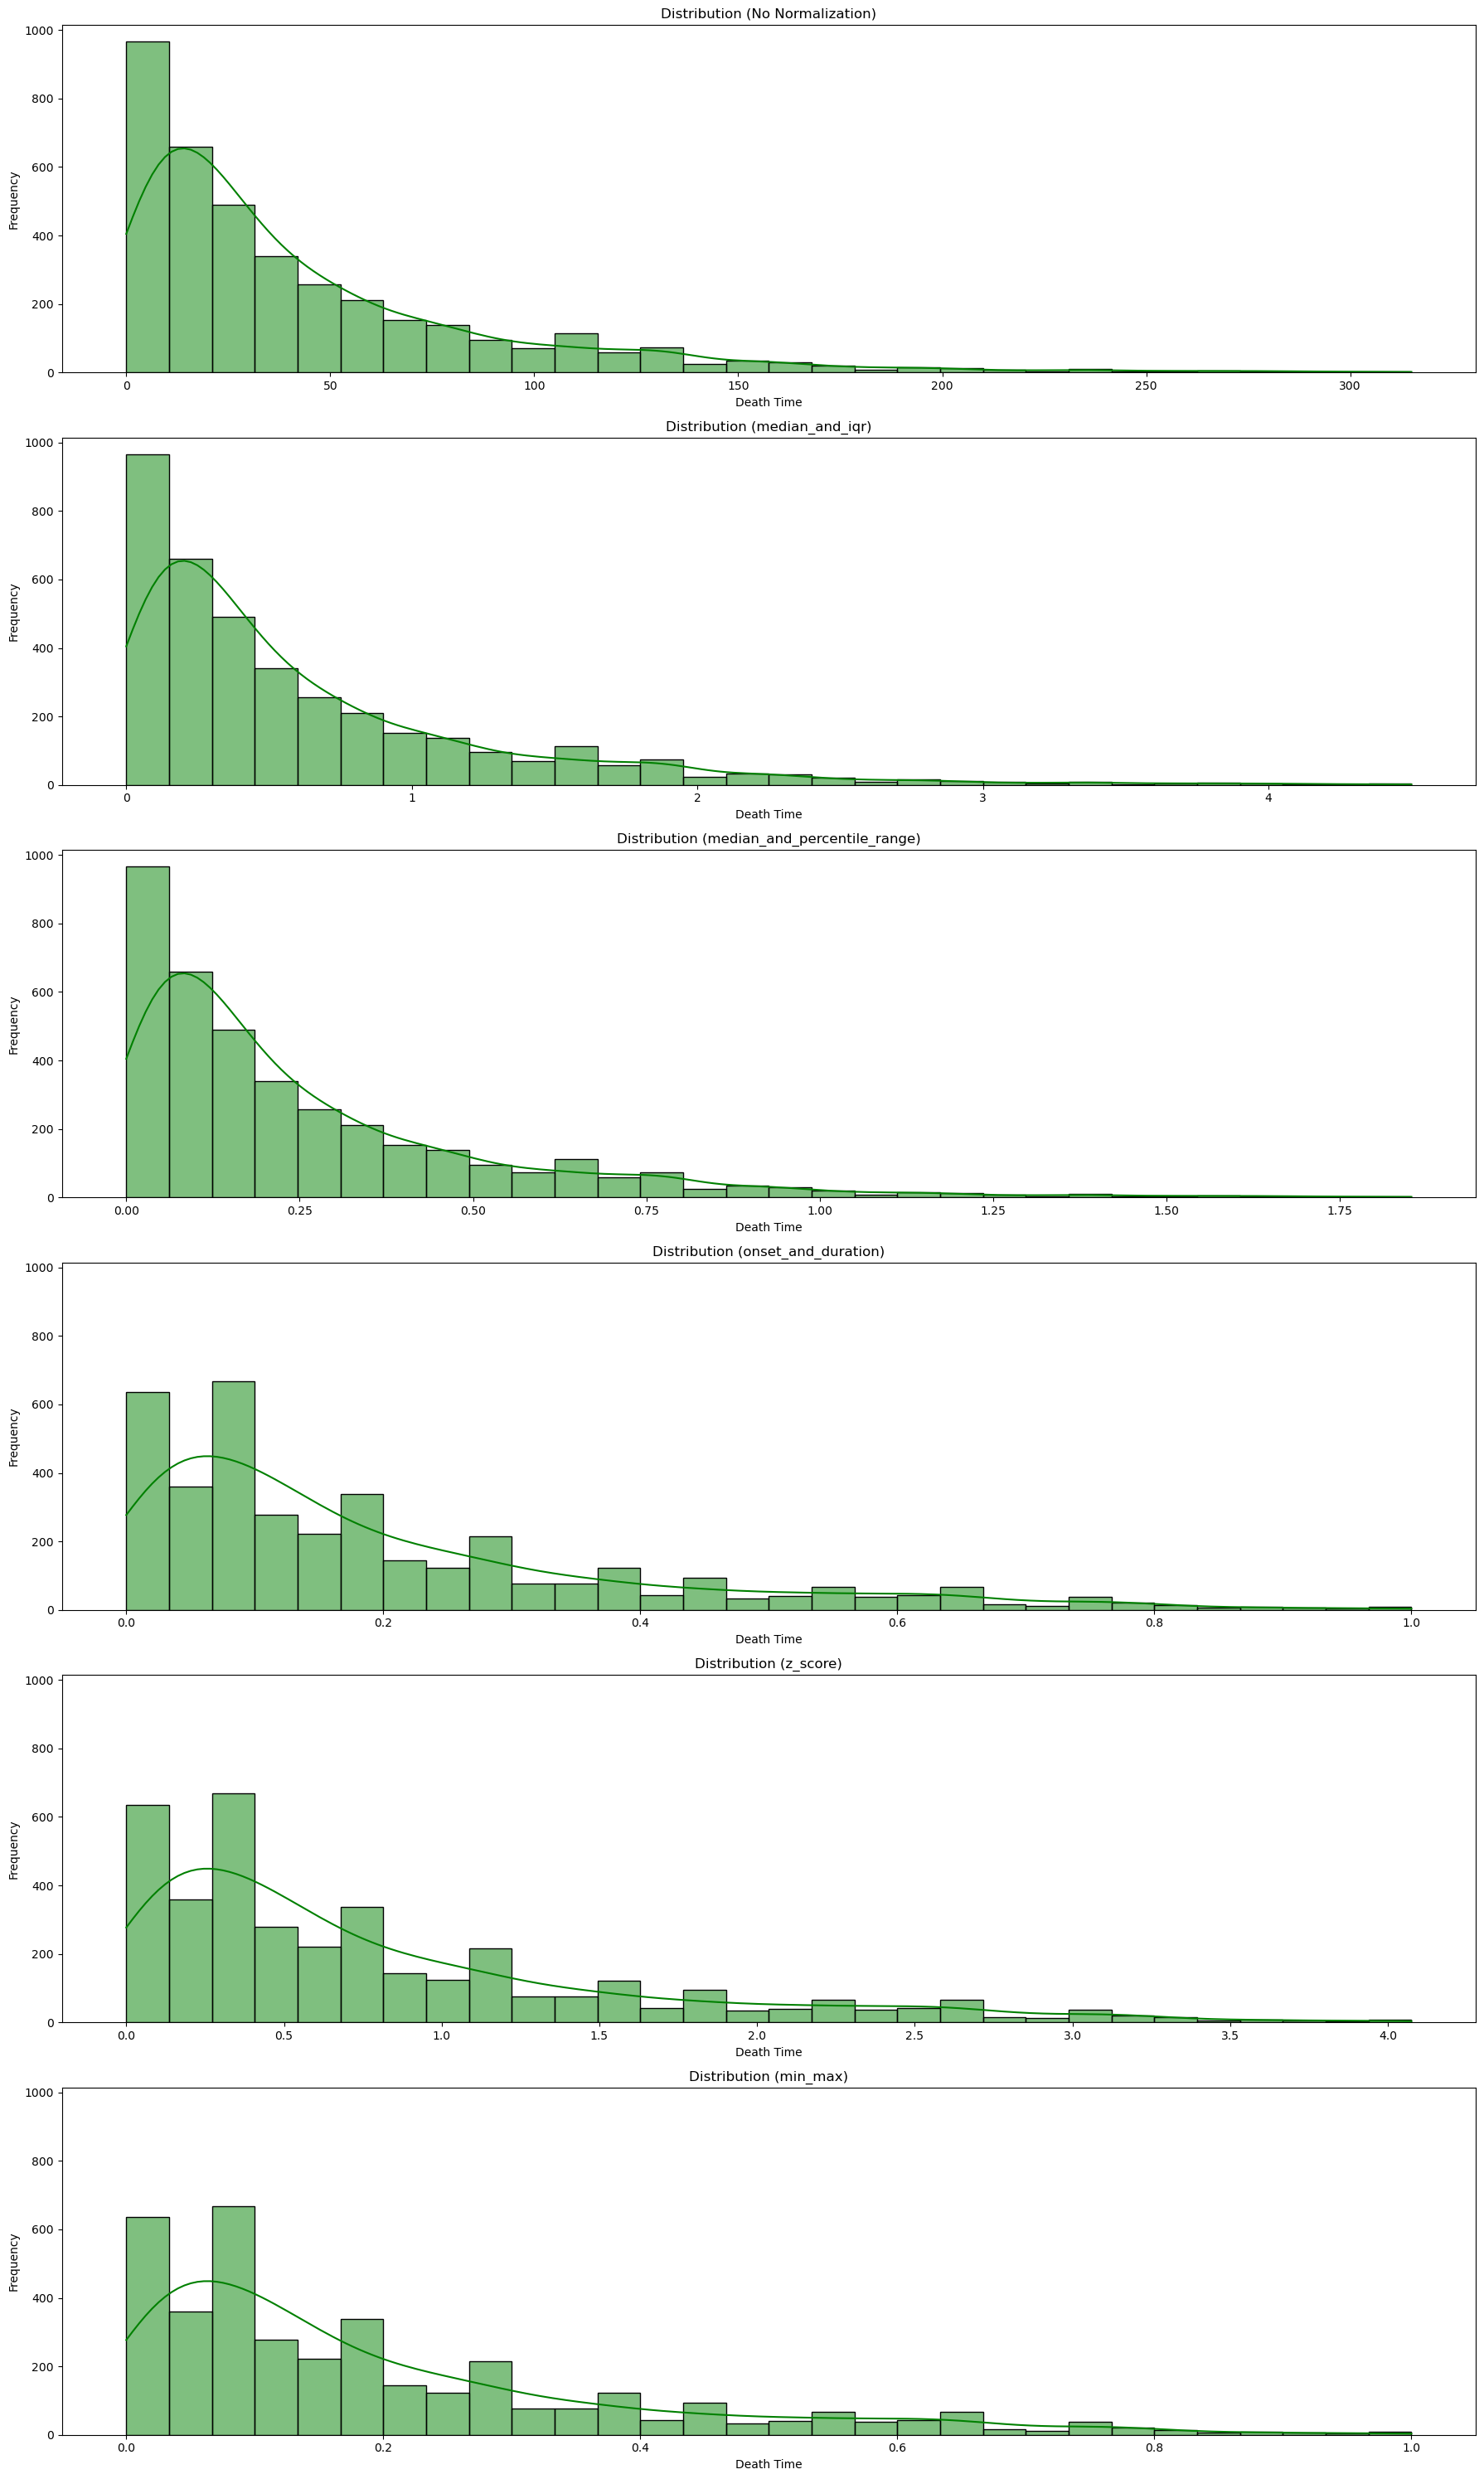

Processing file: purecolony3_sytox_based.csv


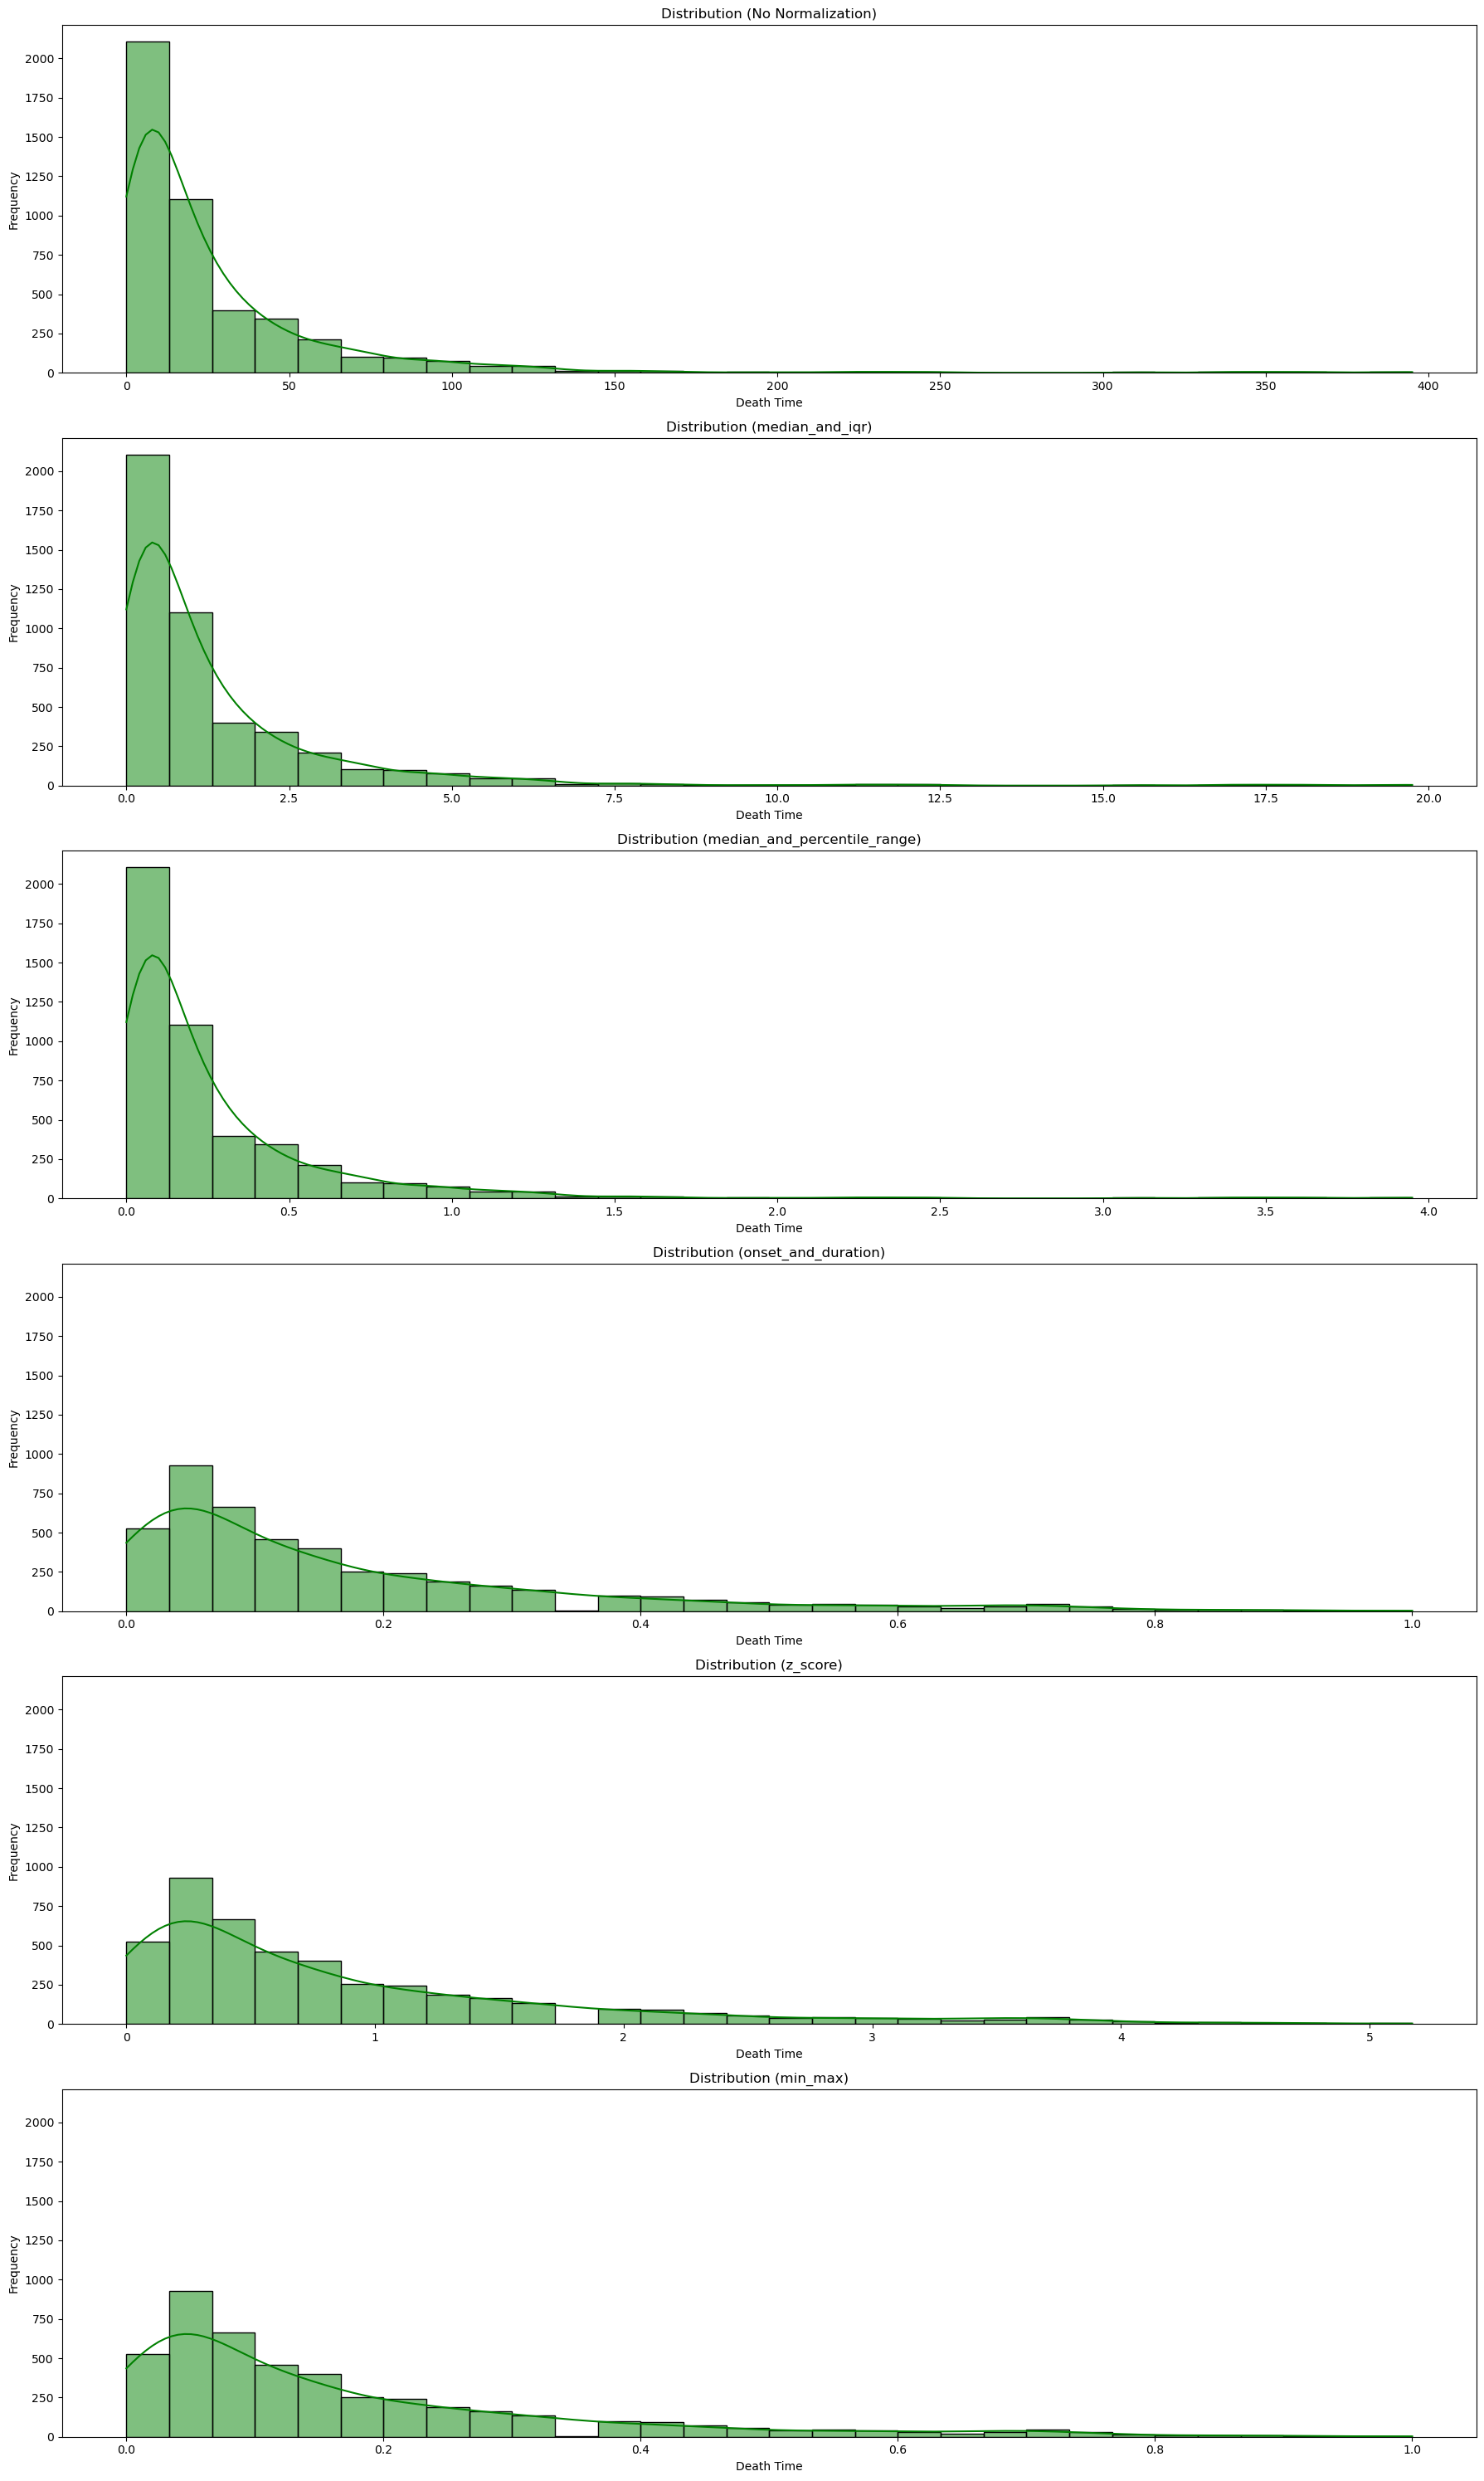

Processing file: purecolony2_sytox_based.csv


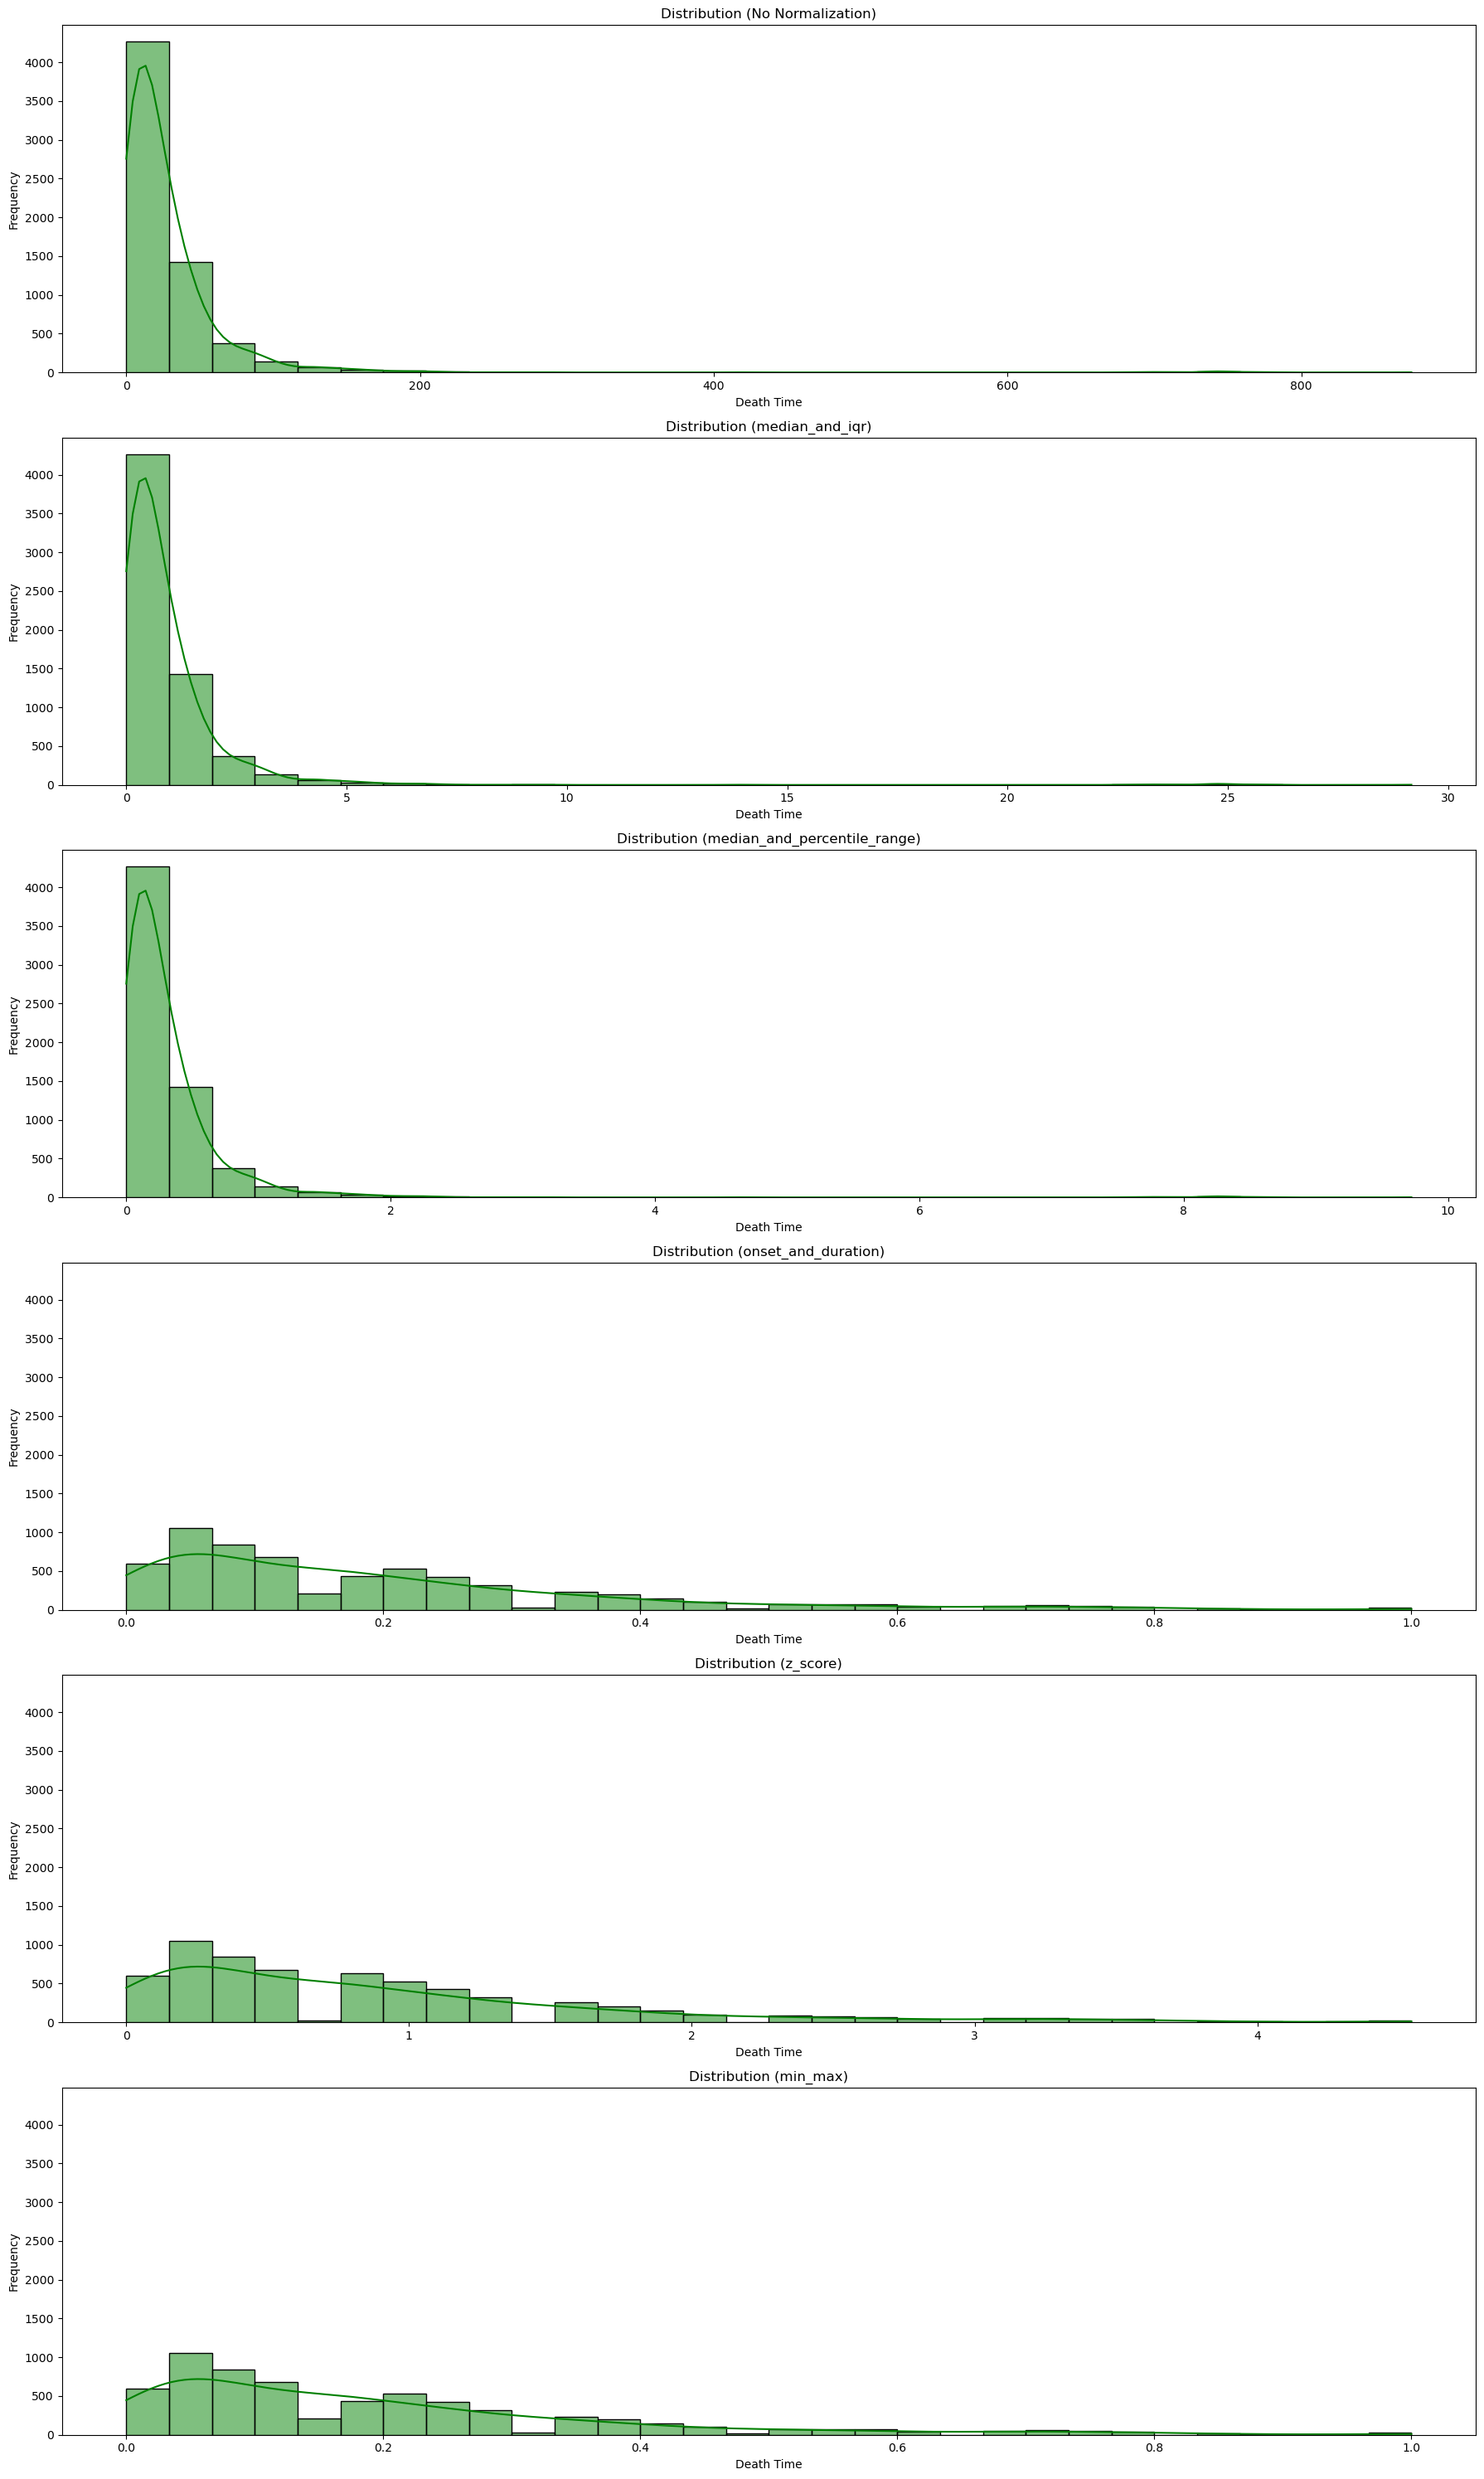

In [2]:
# Directory containing the files
dir_files = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'

# Dictionary to store results
death_quanta_results = {}

# Iterate over files in the directory
for file in os.listdir(dir_files):
    if file.endswith('.csv') :#and 'mix' in file.lower():  # Ensure only CSV files are processed
        
        file_path = os.path.join(dir_files, file)
        if 'mix' in file.lower() or 'nec' in file.lower() or 'apop' in file.lower() or 'out' in file.lower() or 'skt' in file.lower() or 'field3' in file.lower():
            continue  # Skip files with 'mix' in their name
        # Read the CSV file
        print(f"Processing file: {file}")
        df = pd.read_csv(file_path)
        
        # Extract necessary columns
        cells_location = df[["cell_x", "cell_y"]].values
        death_times = df['death_time'].values
        death_modes = df["Mode"].values if "Mode" in df.columns else None
        
        # Apply DeathQuanta
        dist_threshold = 100  # microns
        de_qu = DeathQuanta(
            cells_xy=cells_location,
            death_times=death_times,
            death_modes=death_modes,
            dist_threshold=dist_threshold,
            filter_neighbors_by_distance=True,
            neighbors_level=1,
            pure_type = "necrosis" if "nec" in file else "apoptosis",
        )
    
     # Get unique modes
        normalization_types = [None, 'median_and_iqr', 'median_and_percentile_range', 'onset_and_duration', 'z_score', 'min_max']
        fig, axes = plt.subplots(len(normalization_types), 1, figsize=(18, 5 * len(normalization_types)), sharey=True)

        for i, n_type in enumerate(normalization_types):
            # Apply DeathQuanta with different normalization types
            de_qu = DeathQuanta(
            cells_xy=cells_location,
            death_times=death_times,
            death_modes=death_modes,
            dist_threshold=dist_threshold,
            normalize=True if n_type else False,
            n_type=n_type if n_type else None,
            filter_neighbors_by_distance=True,
            neighbors_level=1,
            pure_type="necrosis" if "nec" in file else "apoptosis",
            )
            
            # Get normalized death times
            normalized_death_times = de_qu.get_org_deltaTOD_neighbors_pairs()

            # Plot the distribution
            sns.histplot(normalized_death_times, bins=30, kde=True, ax=axes[i], color='blue' if 'apop' in file else 'green')
            axes[i].set_title(f'Distribution ({n_type if n_type else "No Normalization"})')
            axes[i].set_xlabel('Death Time')
            axes[i].set_ylabel('Frequency')
            axes[i].grid(False)

        plt.tight_layout()
        plt.grid(False)
        plt.show()


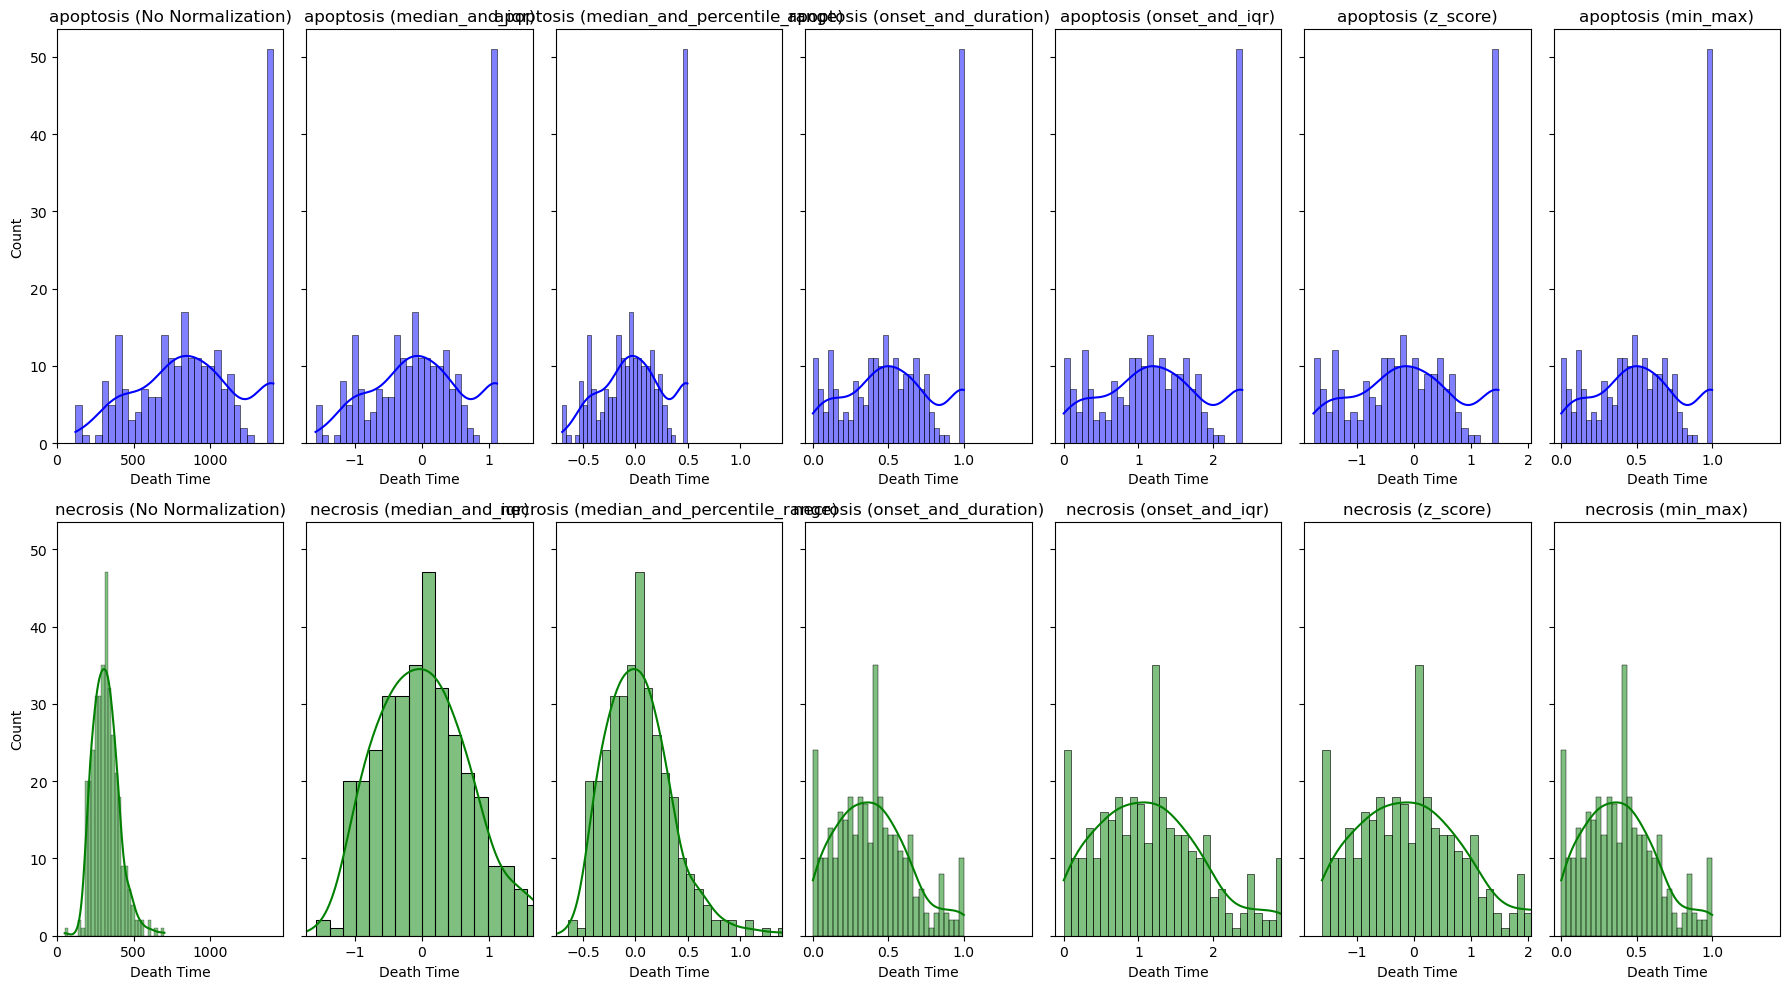

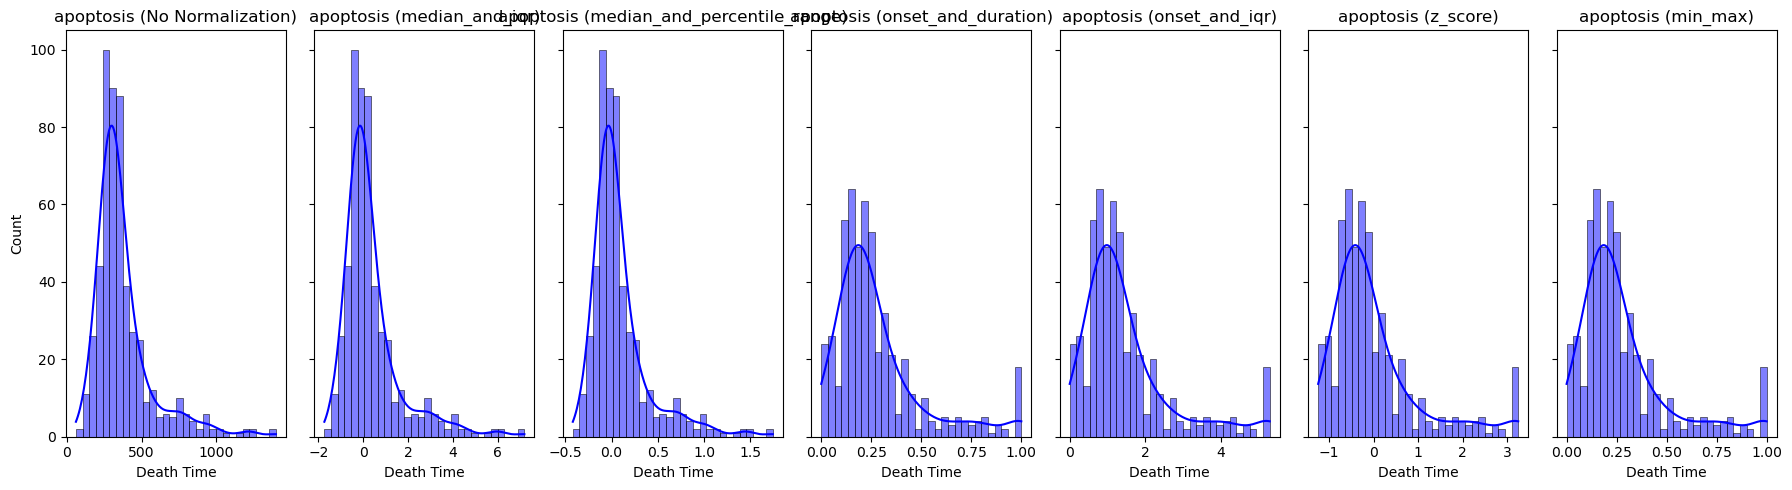

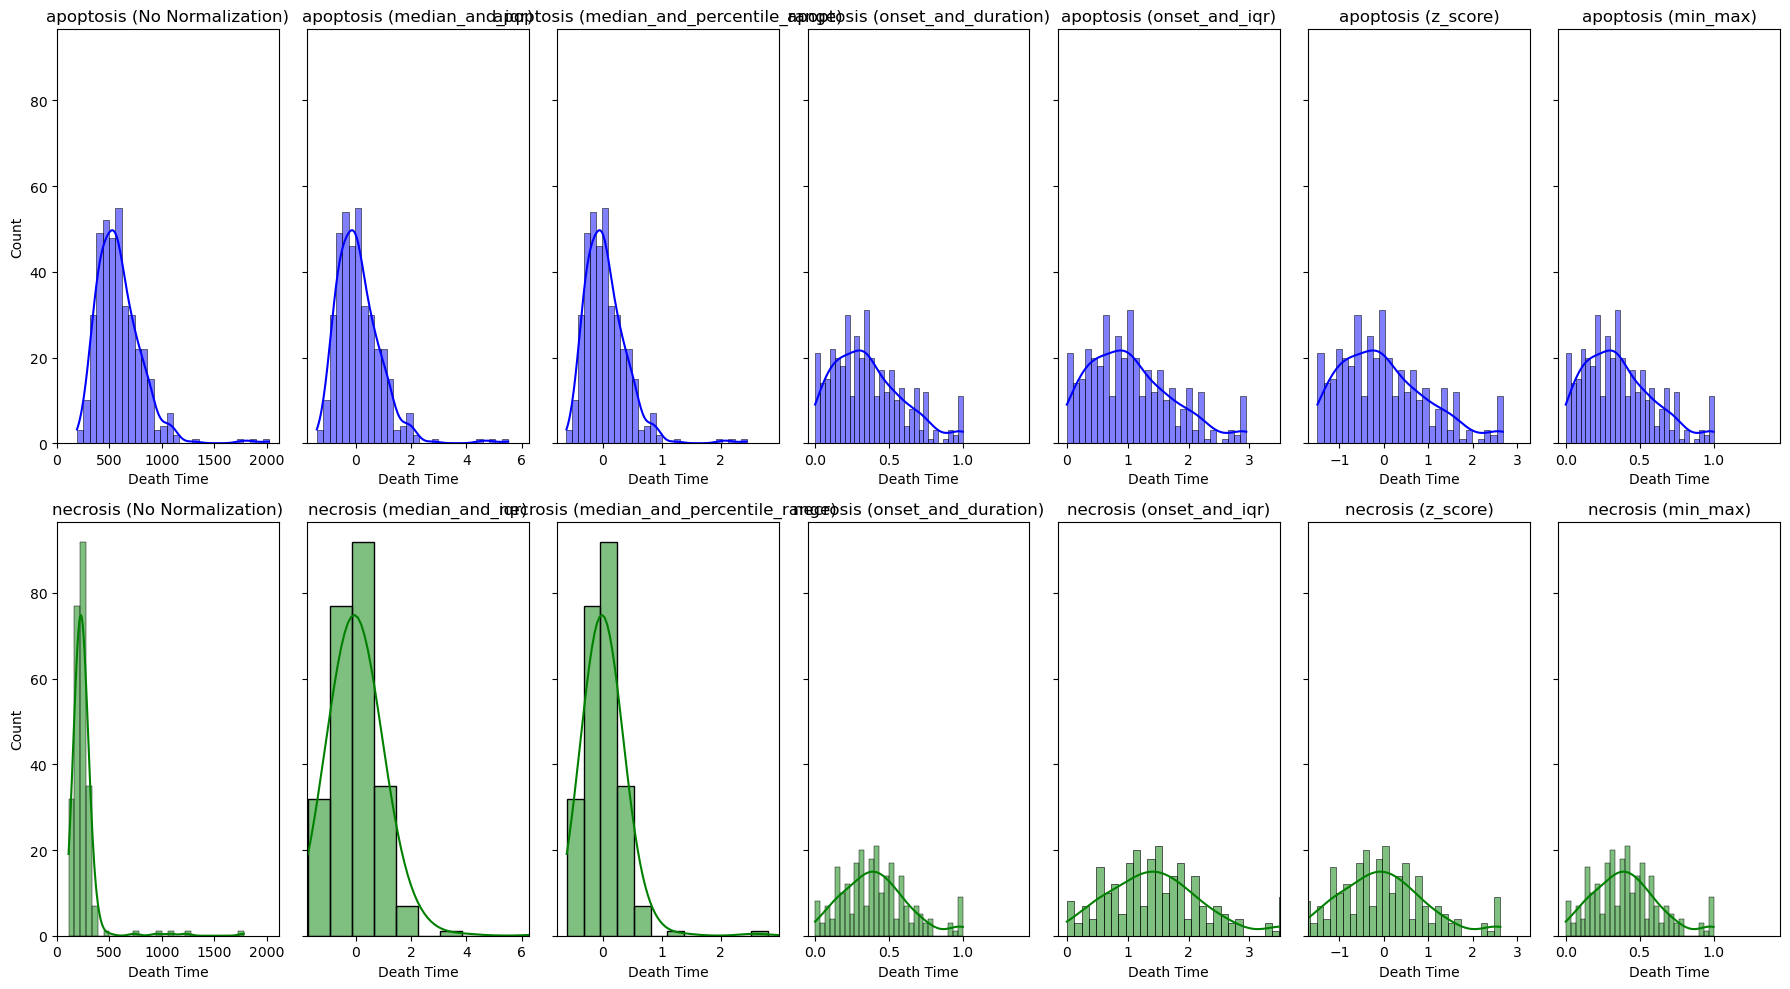

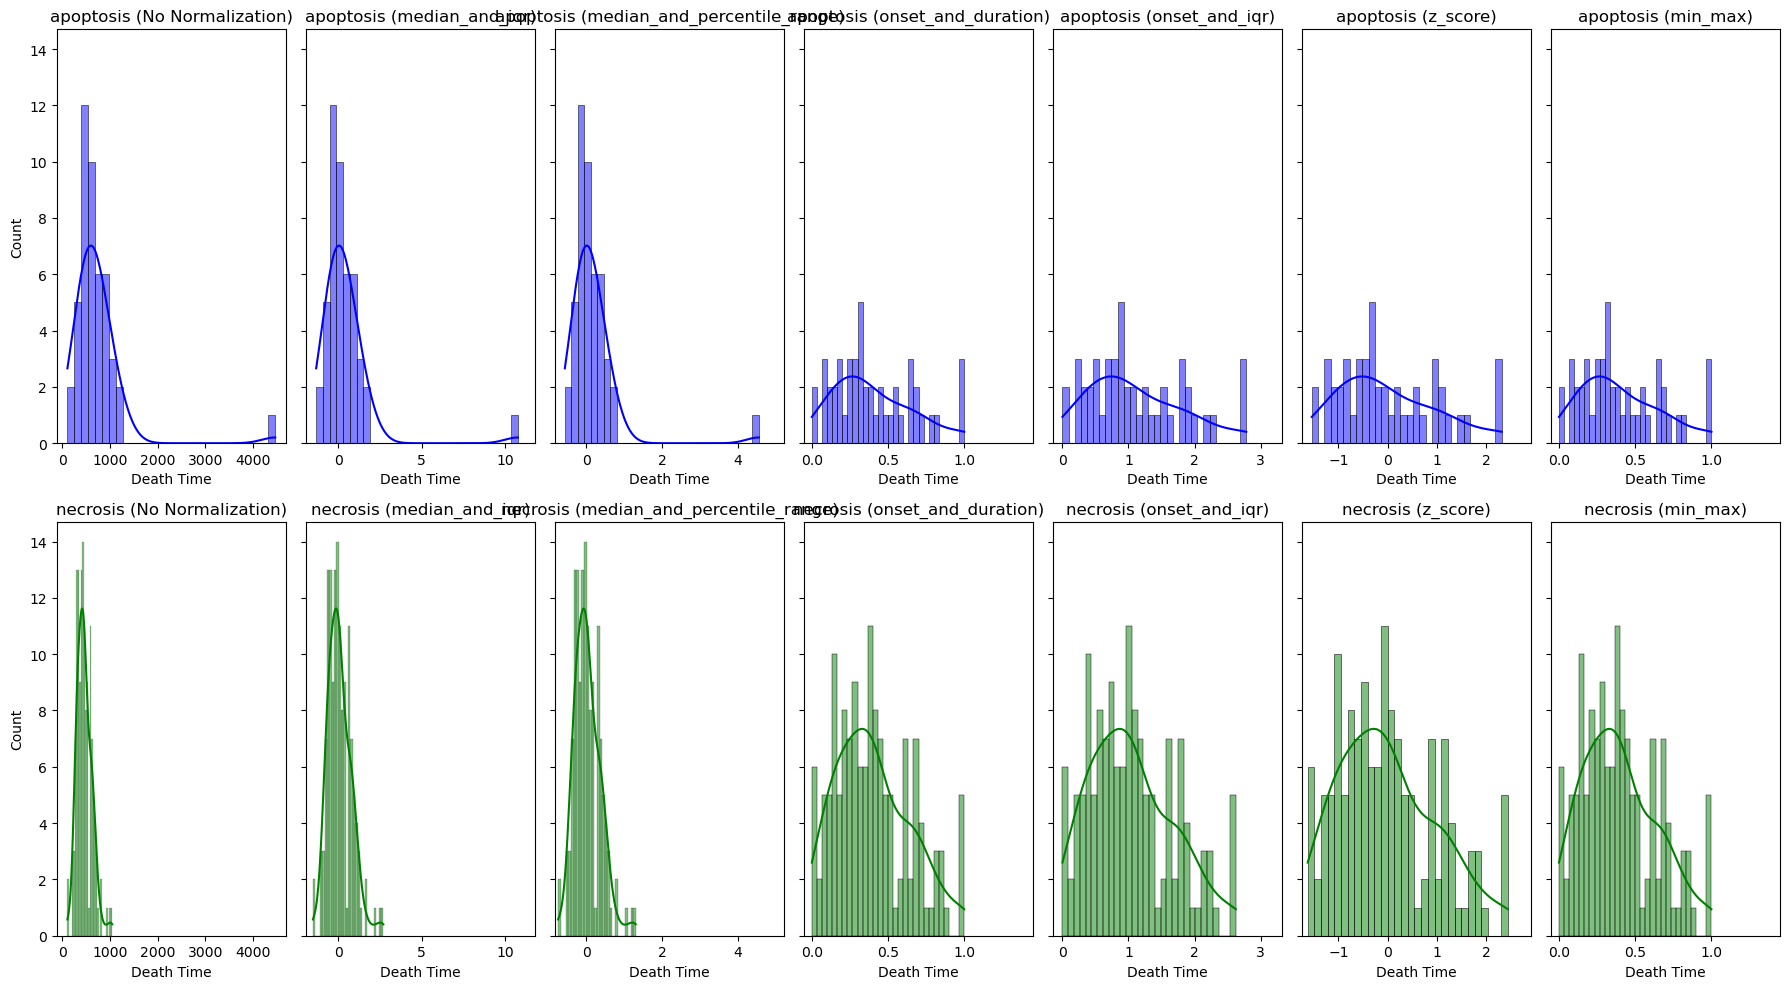

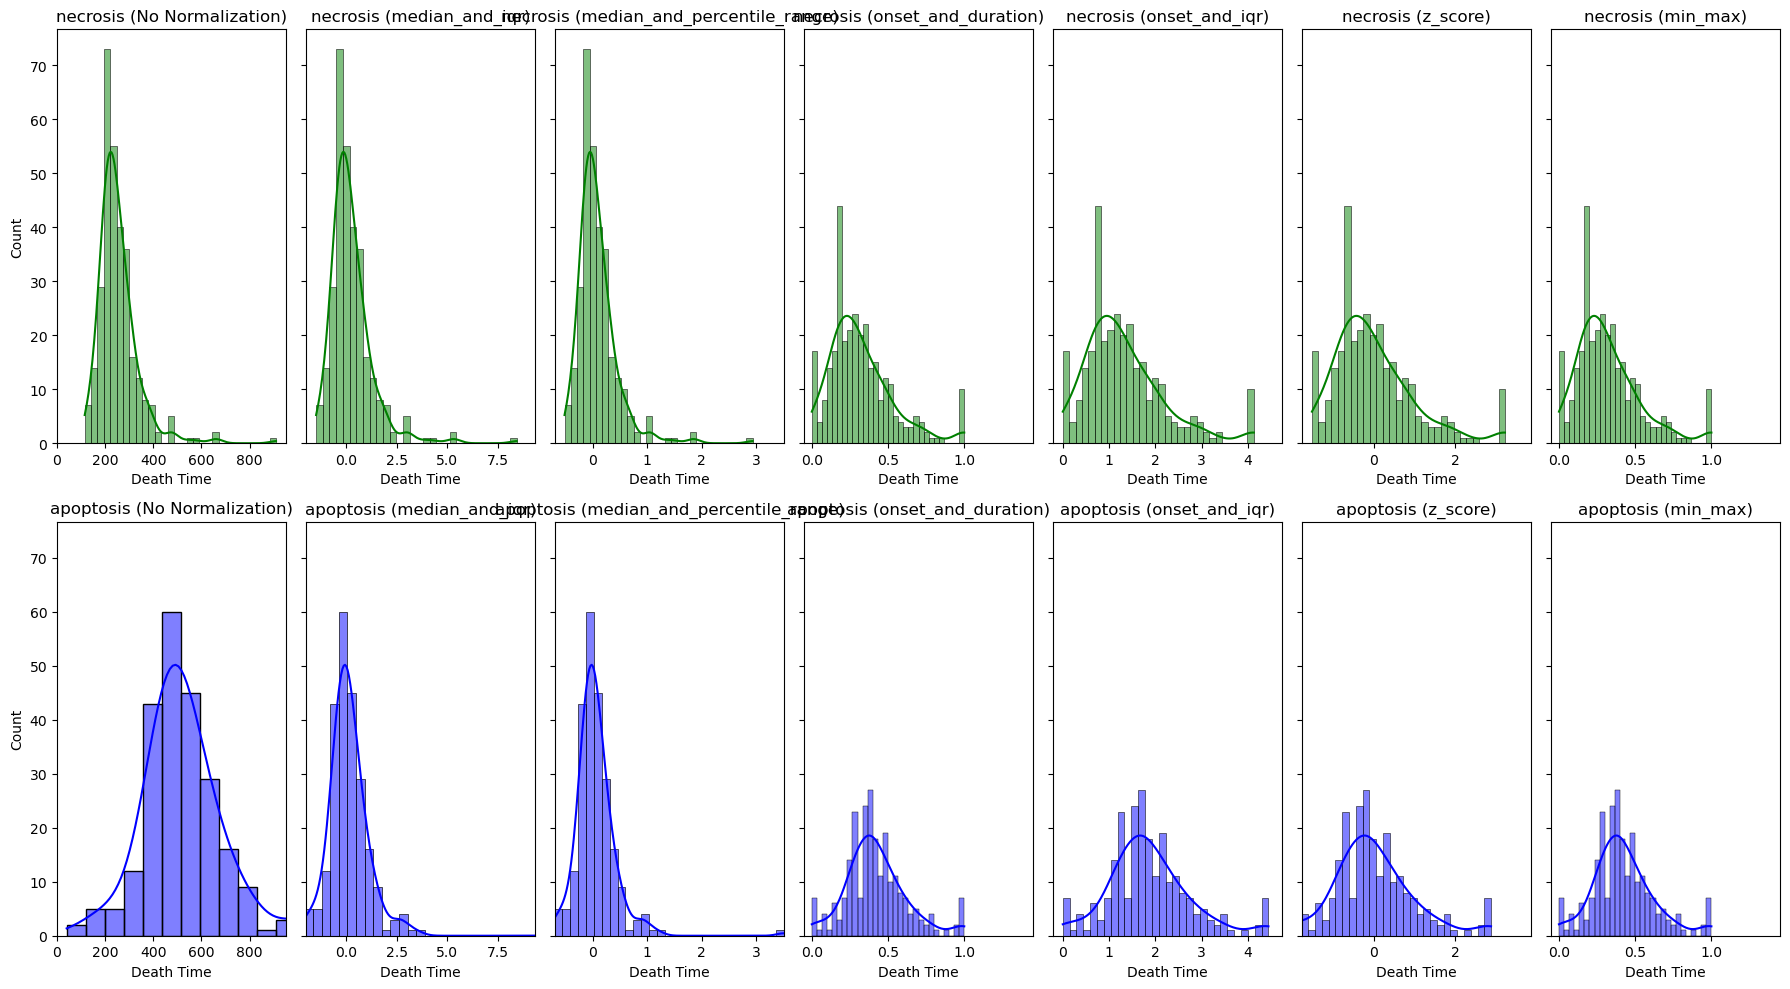

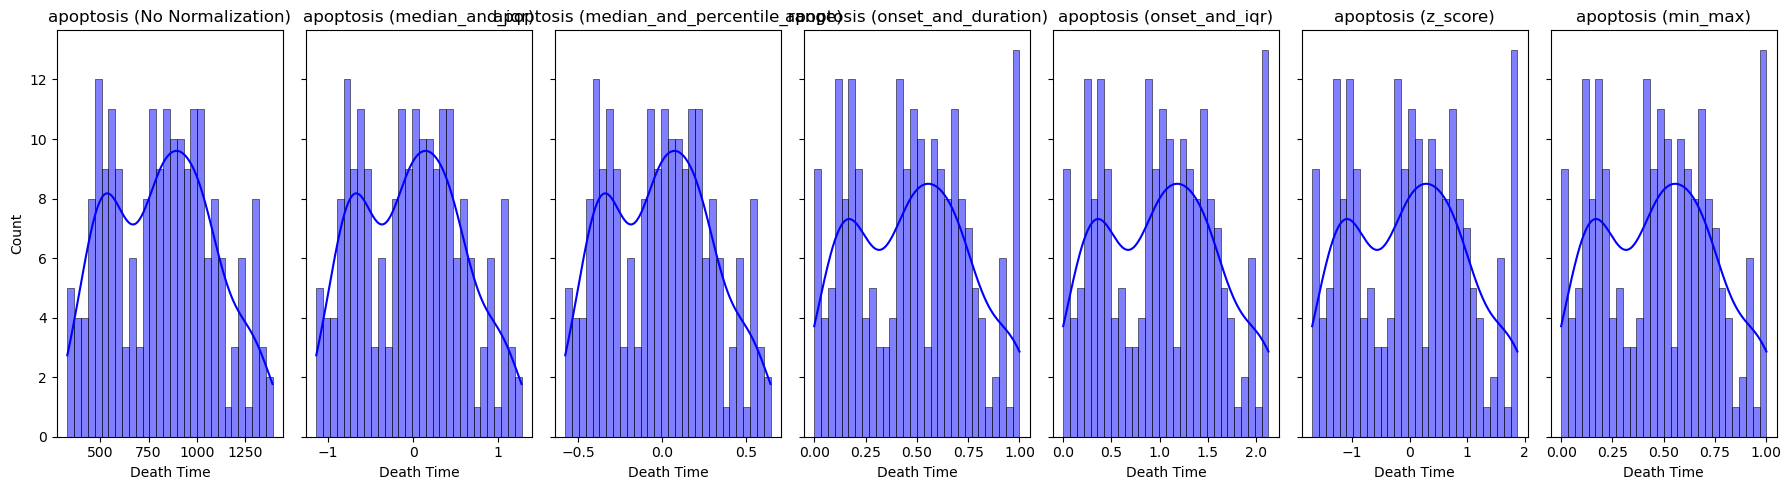

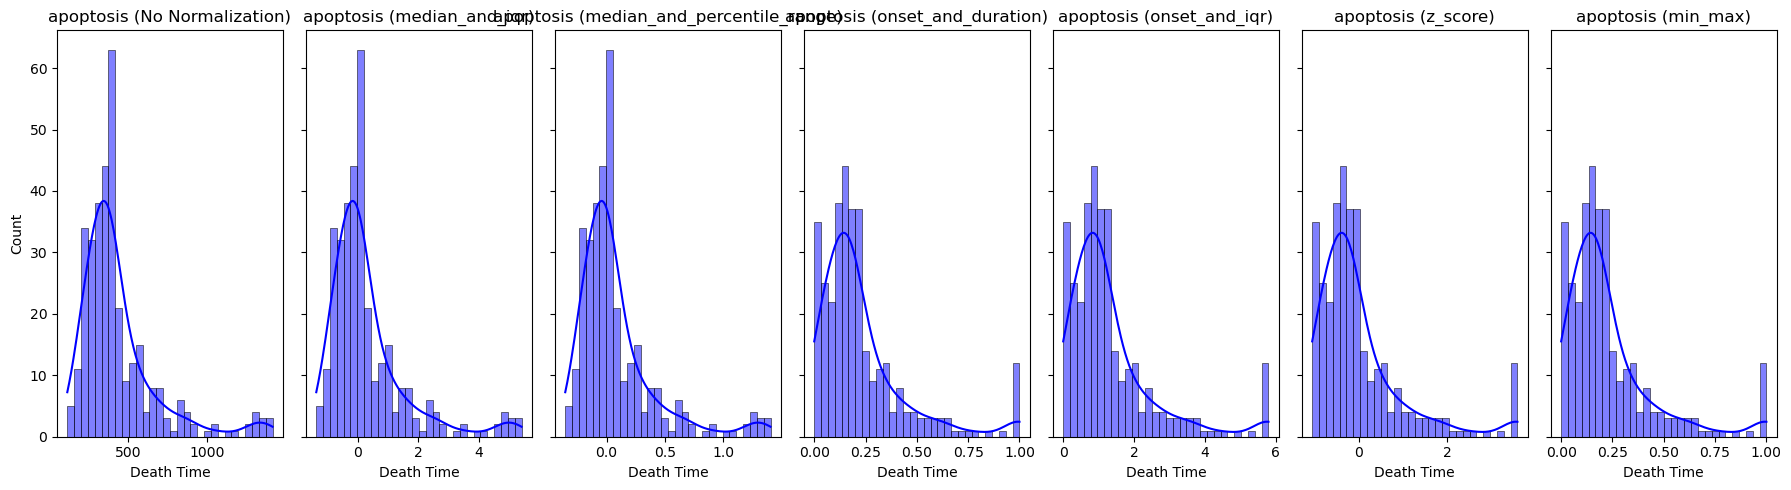

In [4]:
# Directory containing the files
dir_files = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'

# Dictionary to store results
death_quanta_results = {}
dist_threshold = 100  # microns
# Iterate over files in the directory
for file in os.listdir(dir_files):
    if file.endswith('.csv') and 'mix' in file.lower():  # Ensure only CSV files are processed
        file_path = os.path.join(dir_files, file)
        
        # Read the CSV file
        df = pd.read_csv(file_path)
        
        # Extract necessary columns
        cells_location = df[["cell_x", "cell_y"]].values
        death_times = df['death_time'].values
        death_modes = df["Mode"].values if "Mode" in df.columns else None
        
        # Check if there is more than one mode in the file
        if death_modes is None:
            df["Mode"] = ["necrosis" if "nec" in file or 'pure' in file else "apoptosis"]* len(death_times)
        unique_modes = df['Mode'].unique()
        unique_modes = [mode for mode in unique_modes if mode in ["necrosis", "apoptosis"]]
        fig, axes = plt.subplots(len(unique_modes), 7, figsize=(18, 5 * len(unique_modes)), sharey=True)
        for i, mode in enumerate(unique_modes):
        # Filter data by mode
            subset = df[df['Mode'] == mode]
            cells_location_subset = subset[["cell_x", "cell_y"]].values
            death_times_subset = subset['death_time'].values
            death_modes_subset = subset["Mode"].values if "Mode" in subset.columns else None

            normalization_types = [None, 'median_and_iqr', 'median_and_percentile_range', 'onset_and_duration', 'onset_and_iqr', 'z_score', 'min_max']

            for j, n_type in enumerate(normalization_types):
                # Apply DeathQuanta with different normalization types
                de_qu = DeathQuanta(
                cells_xy=cells_location_subset,
                death_times=death_times_subset,
                death_modes=death_modes_subset,
                dist_threshold=dist_threshold,
                normalize=True if n_type else False,
                n_type=n_type if n_type else None,
                filter_neighbors_by_distance=True,
                neighbors_level=1,
                )

                # Get normalized death times
                normalized_death_times = de_qu.death_times.copy()

                # Plot the distribution.
                if len(unique_modes) > 1:
                    sns.histplot(normalized_death_times, bins=30, kde=True, ax=axes[i, j], color='blue' if mode == 'apoptosis' else 'green')
                    axes[i, j].set_title(f'{mode} ({n_type if n_type else "No Normalization"})')
                    # Set uniform x-axis limits for each column
                    x_min = min(ax.get_xlim()[0] for ax in axes[:, j])
                    x_max = max(ax.get_xlim()[1] for ax in axes[:, j])
                    for ax in axes[:, j]:
                        ax.set_xlim(x_min, x_max+0.2)
                    axes[i, j].set_xlabel('Death Time')
                else:
                    sns.histplot(normalized_death_times, bins=30, kde=True, ax=axes[j], color='blue' if mode == 'apoptosis' else 'green')
                    axes[ j].set_title(f'{mode} ({n_type if n_type else "No Normalization"})')
                    # Set uniform x-axis limits for each column
                    x_min = min(ax.get_xlim()for ax in axes)
                    x_max = max(ax.get_xlim() for ax in axes)

                    axes[j].set_xlabel('Death Time')

        plt.tight_layout()
        plt.show()
            # break  # Remove this line if you want to process all files
        



## overlapping Death modes in same plot

Processing file: 7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv


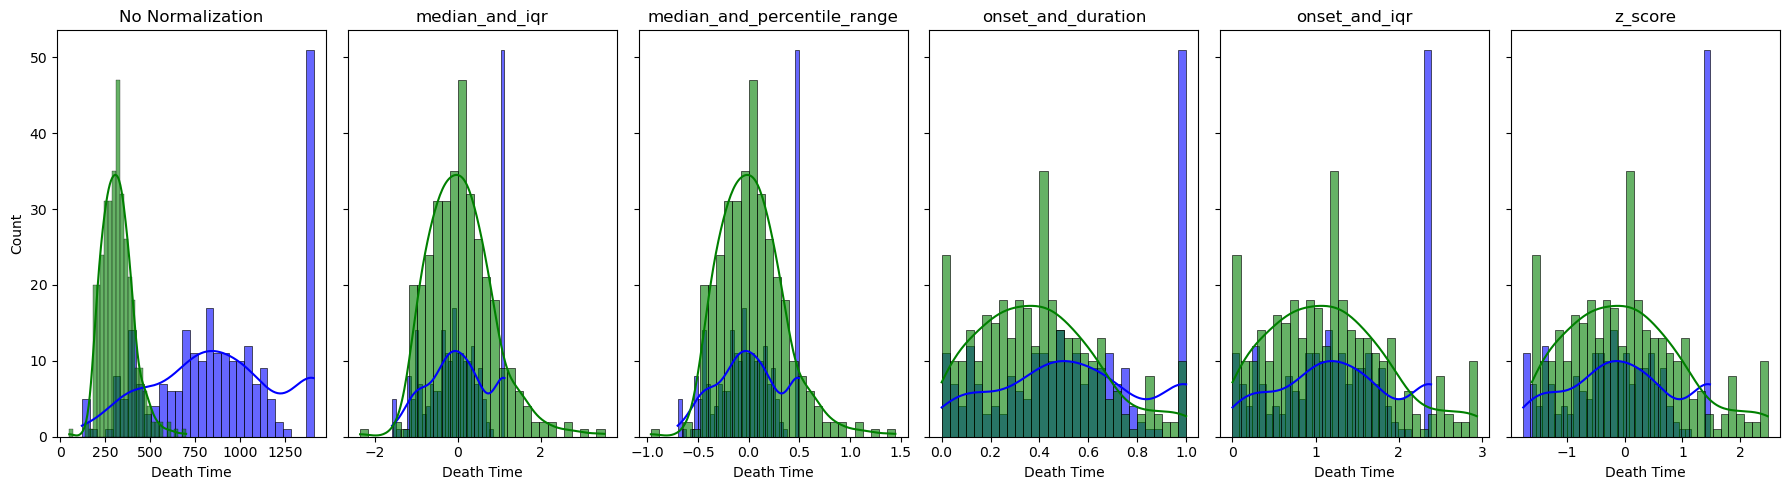

Processing file: Field14-002_ROI#1_annotation_mixed.csv


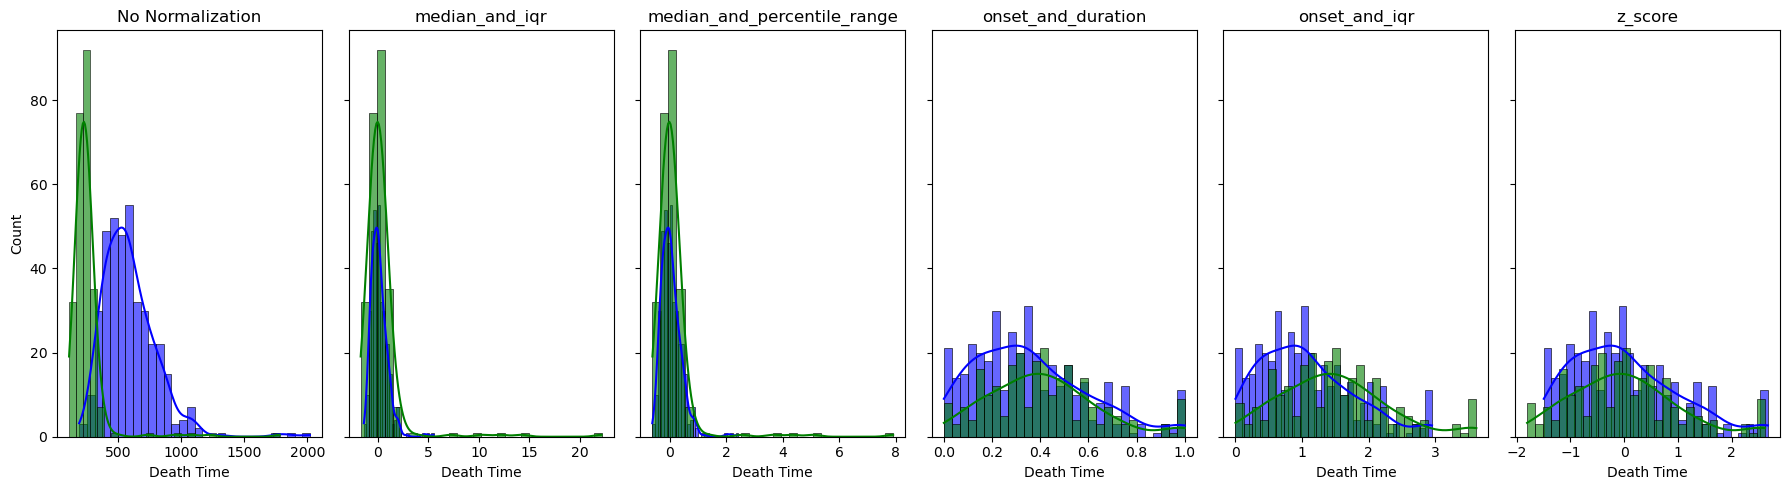

Processing file: 7-20-23_10arednuclei_ROI#10_annotation_mixed.csv


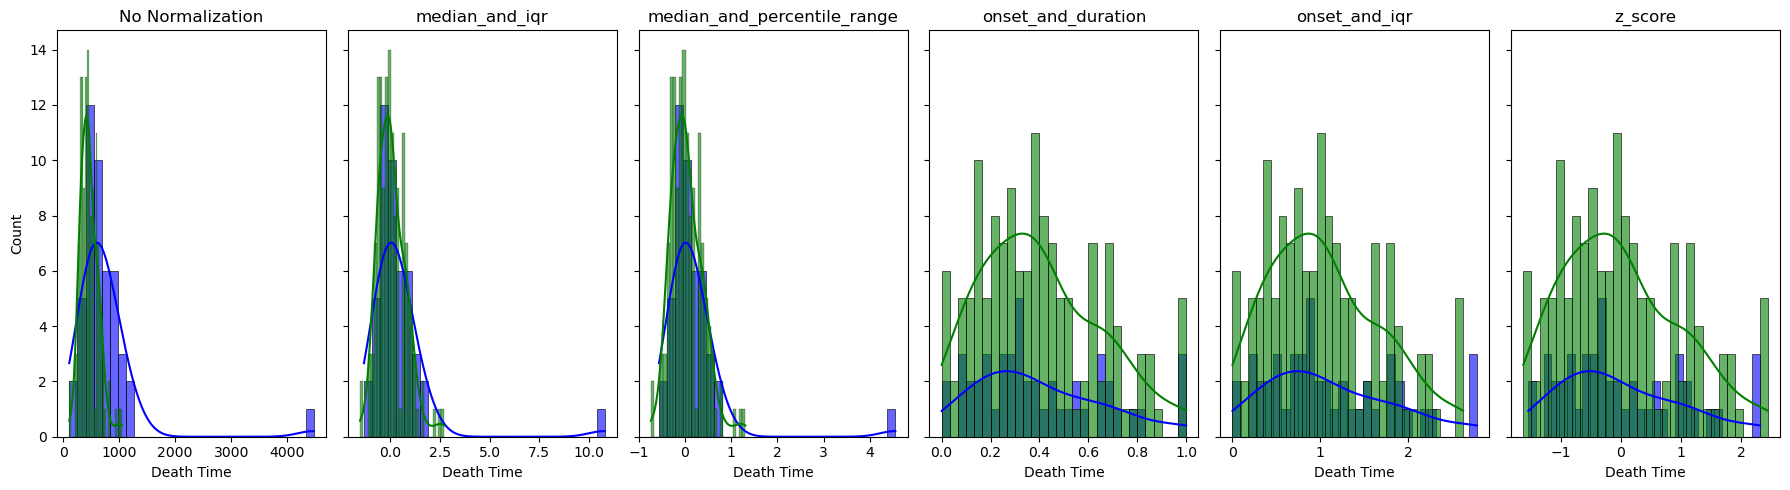

Processing file: field13_crop-001_ROI#1_annotation_mixed.csv


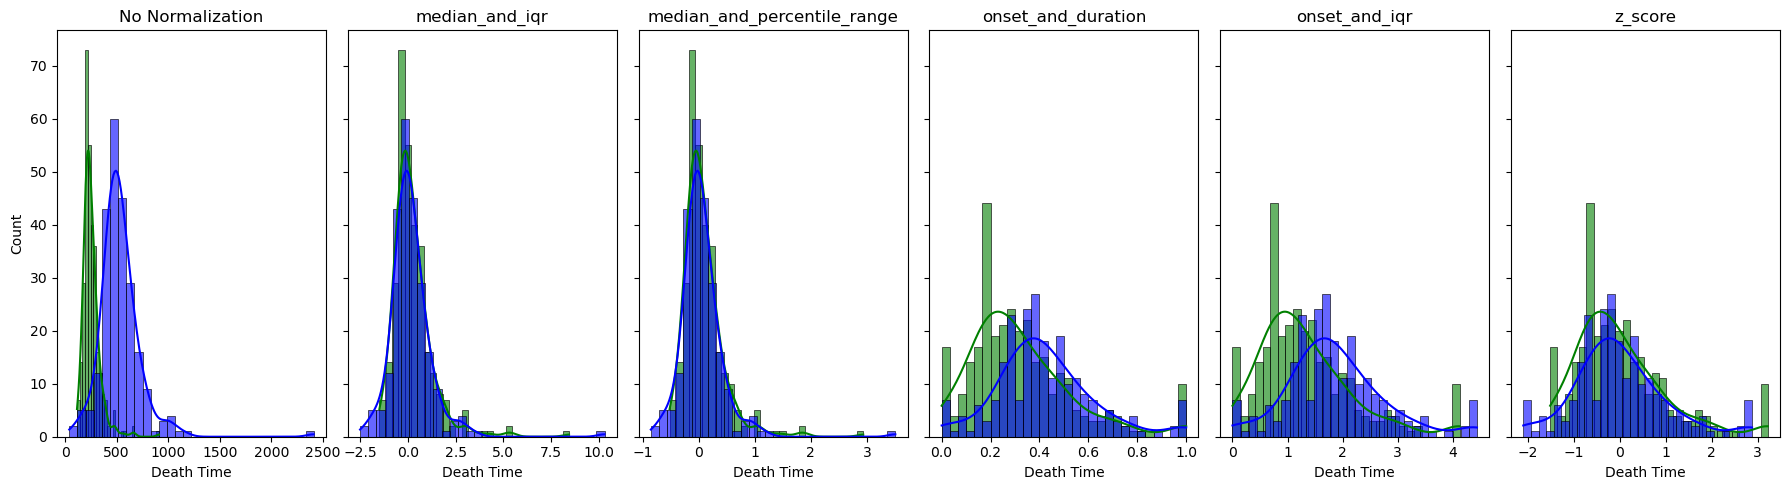

In [4]:
# Directory containing the files
dir_files = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'

# Dictionary to store results
death_quanta_results = {}
dist_threshold = 100  # microns
# Iterate over files in the directory
for file in os.listdir(dir_files):
    if file.endswith('.csv'):  # Ensure only CSV files are processed
        file_path = os.path.join(dir_files, file)
        if 'mixed' not in file.lower():
            continue
        
        # Read the CSV file
        df = pd.read_csv(file_path)
        
        # Extract necessary columns
        cells_location = df[["cell_x", "cell_y"]].values
        death_times = df['death_time'].values
        death_modes = df["Mode"].values if "Mode" in df.columns else None
        
        # Check if there is more than one mode in the file
        if death_modes is None:
            df["Mode"] = ["necrosis" if "nec" in file or 'pure' in file else "apoptosis"] * len(death_times)
        unique_modes = df['Mode'].unique()
        unique_modes = [mode for mode in unique_modes if mode in ["necrosis", "apoptosis"]]
        
        normalization_types = [None, 'median_and_iqr', 'median_and_percentile_range', 'onset_and_duration', 'onset_and_iqr', 'z_score']
        
        if 'mix' in file.lower():
            print(f"Processing file: {file}")
            fig, axes = plt.subplots(1, len(normalization_types), figsize=(18, 5), sharey=True)
            for j, n_type in enumerate(normalization_types):
                for mode in unique_modes:
                    # Filter data by mode
                    subset = df[df['Mode'] == mode]
                    cells_location_subset = subset[["cell_x", "cell_y"]].values
                    death_times_subset = subset['death_time'].values
                    death_modes_subset = subset["Mode"].values if "Mode" in subset.columns else None

                    # Apply DeathQuanta with different normalization types
                    de_qu = DeathQuanta(
                        cells_xy=cells_location_subset,
                        death_times=death_times_subset,
                        death_modes=death_modes_subset,
                        dist_threshold=dist_threshold,
                        normalize=True if n_type else False,
                        n_type=n_type if n_type else None,
                        filter_neighbors_by_distance=True,
                        neighbors_level=1,
                    )

                    # Get normalized death times
                    normalized_death_times = de_qu.death_times.copy()

                    # Plot the distribution
                    sns.histplot(
                        normalized_death_times, 
                        bins=30, 
                        kde=True, 
                        ax=axes[j], 
                        label=mode, 
                        alpha=0.6, 
                        color='green' if mode == 'necrosis' else 'blue'
                    )
                    axes[j].set_title(f'{n_type if n_type else "No Normalization"}')
                    axes[j].set_xlabel('Death Time')
                axes[j].legend().remove()  # Remove legend if not needed
            plt.tight_layout()
            plt.show()
        else:
            continue


In [ ]:
# Create a new column combining MajorGroup and MinorGroup for plotting
df['Group'] = df['MajorGroup'] + " (" + df['MinorGroup'] + ")"

# Plot boxplot
plt.figure(figsize=(16, 8))
sns.set_style("white")
sns.boxplot(x='Group', y='TOD', data=df, width=0.5, palette='pastel', showfliers=False)

# Annotate mean for each group
for i, label in enumerate(df['Group'].unique()):
    values = df[df['Group'] == label]['TOD']
    mean = np.mean(values)
    plt.scatter(i, mean, color='black', marker='D', label='Mean' if i == 0 else "", zorder=3)

plt.xticks(fontsize=10, rotation=90, ha='right', ticks=range(len(df['Group'].unique())))
plt.yticks(fontsize=12)

# Format plot
plt.title('Boxplot of TOD by Major and Minor Groups')
plt.ylabel('TOD')
plt.xlabel('Groups')
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_major_minor_groups.svg", format="svg", dpi=300)
plt.show()


# Normalization of TODs

In [11]:
import os
import sys
import shutil
import math
import warnings
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import *
from enum import Enum
from scipy.spatial import Voronoi
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import LabelEncoder
from scipy.stats import wasserstein_distance
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.utils import get_experiment_cell_death_times_by_specific_siliding_window,read_experiment_cell_xy_and_death_times
from src.NucleationAndPropagationMeasurements import replace_ugly_long_name
from src.quanta_utils import get_neighbors
from src.DeathQuanta import DeathQuanta

## OLD data

In [3]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/FullFOVsData/OldDataYishaia/Experiments_XYT_CSV/OriginalTimeMinutesData/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/FullFOVsData/OldDataYishaia/Experiments_XYT_CSV/ExperimentsMetaData.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(len(exp_names)):
    if "compressed" in exp_names[idx] or "compressed" in exp_names[idx].lower():
        continue
    try: 
        print(exp_names[idx])
        exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
        csv_file = pd.read_csv(exp_full_path)
        dist_threshold = 100 # microns
        cells_location = csv_file[["cell_x","cell_y"]].values
        di_times = csv_file[['death_time']].values
        death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else []
        name = replace_ugly_long_name(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Treatment"].values[0],
                            meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Cell Line"].values[0])
        de_qu = DeathQuanta(cells_xy=cells_location,
                            death_times=di_times, 
                            death_modes=death_modes,
                            dist_threshold=dist_threshold,
                            filter_neighbors_by_distance=True,
                            neighbors_level=1,
                            pure_type = name)
        tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
        if name not in group_data:
            group_data[name] = {}
        group_data[name][exp_names[idx]]= tod_pairs_1 # tod_pairs_1.get('apoptosis', []) + tod_pairs_1.get('necrosis', []) if isinstance(tod_pairs_1, dict) else tod_pairs_1
    except Exception as e:
        continue

20160820_10A_FB_xy11.csv
20160820_10A_FB_xy12.csv
20160820_10A_FB_xy13.csv
20160820_10A_FB_xy14.csv
20160820_10A_FB_xy15.csv
20160828_10AsgCx43_FB_xy01.csv
20160828_10AsgCx43_FB_xy02.csv
20160828_10AsgCx43_FB_xy03.csv
20160828_10AsgCx43_FB_xy04.csv
20160828_10AsgCx43_FB_xy05.csv
20160828_10AsgCx43_FB_xy06.csv
20160828_10AsgCx43_FB_xy07.csv
20160828_10AsgCx43_FB_xy08.csv
20160828_10AsgCx43_FB_xy09.csv
20160828_10AsgCx43_FB_xy10.csv
20160828_10AsgCx43_FB_xy11.csv
20160828_10AsgCx43_FB_xy13.csv
20160828_10Awt_FB_xy01.csv
20160828_10Awt_FB_xy02.csv
20160828_10Awt_FB_xy03.csv
20160828_10Awt_FB_xy04.csv
20160828_10Awt_FB_xy05.csv
20160909_b16f10_aMSH_xy36.csv
20160909_b16f10_aMSH_xy37.csv
20160909_b16f10_aMSH_xy38.csv
20160909_b16f10_aMSH_xy39.csv
20160909_b16f10_aMSH_xy40.csv
20161129_MCF7_FB_xy11.csv
20161129_MCF7_FB_xy12.csv
20161129_MCF7_FB_xy13.csv
20161129_MCF7_FB_xy14.csv
20161129_MCF7_FB_xy15.csv
20170213_U937_FB_xy1.csv
20170213_U937_FB_xy2.csv
20170213_U937_FB_xy3.csv
20170213_U937

/tmp/ipykernel_743080/449565903.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GroupLabel', y='Difference', data=df,


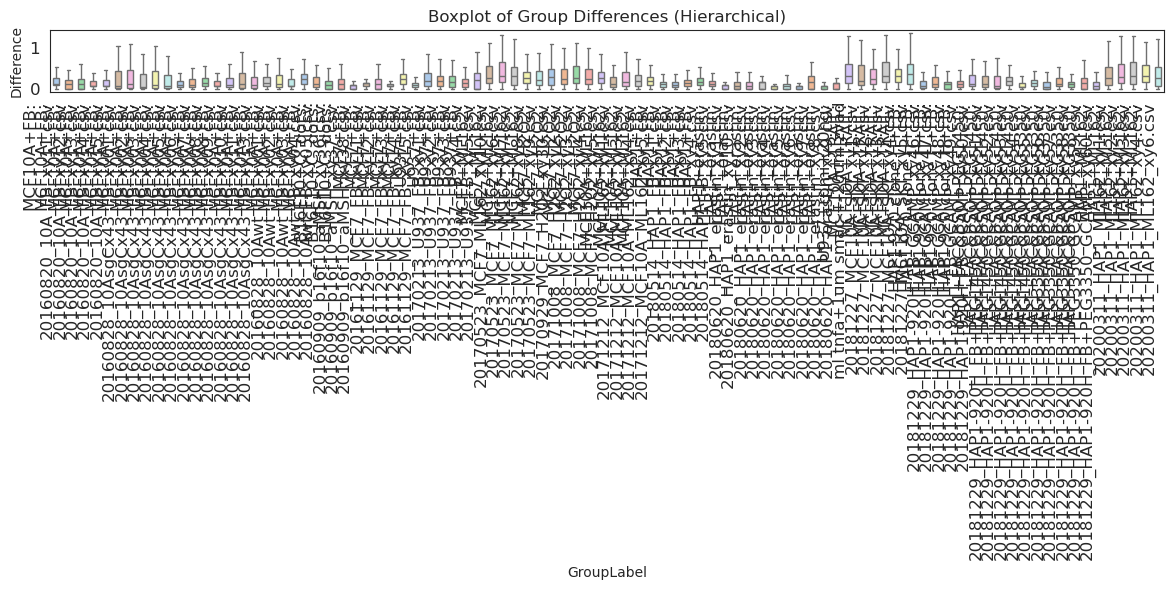

In [5]:
flattened_data = {'Group': [], 'Difference': []}
# Remove "entosis" from group_data
filtered_group_data = {}
for group_name, subgroups in group_data.items():
    if isinstance(subgroups, dict):  # Check if subgroups exist
        filtered_subgroups = {subgroup_name: arrays for subgroup_name, arrays in subgroups.items() if subgroup_name != "entosis"}
        if filtered_subgroups:  # Add only if there are remaining subgroups
            filtered_group_data[group_name] = filtered_subgroups
    else:
        filtered_group_data[group_name] = subgroups  # Keep flat structure unchanged

group_data = filtered_group_data

for group_name, value in group_data.items():
    if isinstance(value, dict):  # Nested: group → subgroup → arrays
        for subgroup_name, arrays in value.items():
            label = f"{group_name}/{subgroup_name}"
            for arr in arrays:
                flattened_data['Group'].extend([label] * len(arr))
                flattened_data['Difference'].extend(arr)
    else:  # Flat list of arrays
        for arr in value:
            flattened_data['Group'].extend([group_name] * len(arr))
            flattened_data['Difference'].extend(arr)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(flattened_data)

# Sort groups hierarchically
df['MainGroup'] = df['Group'].apply(lambda x: x.split('/')[0])
df['SubGroup'] = df['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df['GroupLabel'] = df['MainGroup'] + ':\n' + df['SubGroup']  # for axis formatting

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white") 
sns.boxplot(x='GroupLabel', y='Difference', data=df,
            width=0.5, palette='pastel', showfliers=False)

# Annotate quartiles
for i, label in enumerate(df['GroupLabel'].unique()):
    values = df[df['GroupLabel'] == label]['Difference']
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    # Annotate: uncomment if needed
    # plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    # plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    # plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')
plt.xticks(fontsize=12, rotation=90, ha='right',ticks=range(len(df['GroupLabel'].unique())))
plt.yticks(fontsize=12)
# Format plot
# plt.xticks(rotation=90, ha='right')
plt.title('Boxplot of Group Differences (Hierarchical)')
plt.ylabel('Difference')
plt.grid(False)#, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical.svg", format="svg", dpi=300)
plt.show()
# Save the plot as a high-resolution image suitable for Adobe Illustrator



/tmp/ipykernel_743080/496661313.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='GroupLabel', y='Difference', data=df,
/tmp/ipykernel_743080/496661313.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, fontsize=12, rotation=90, ha='right')


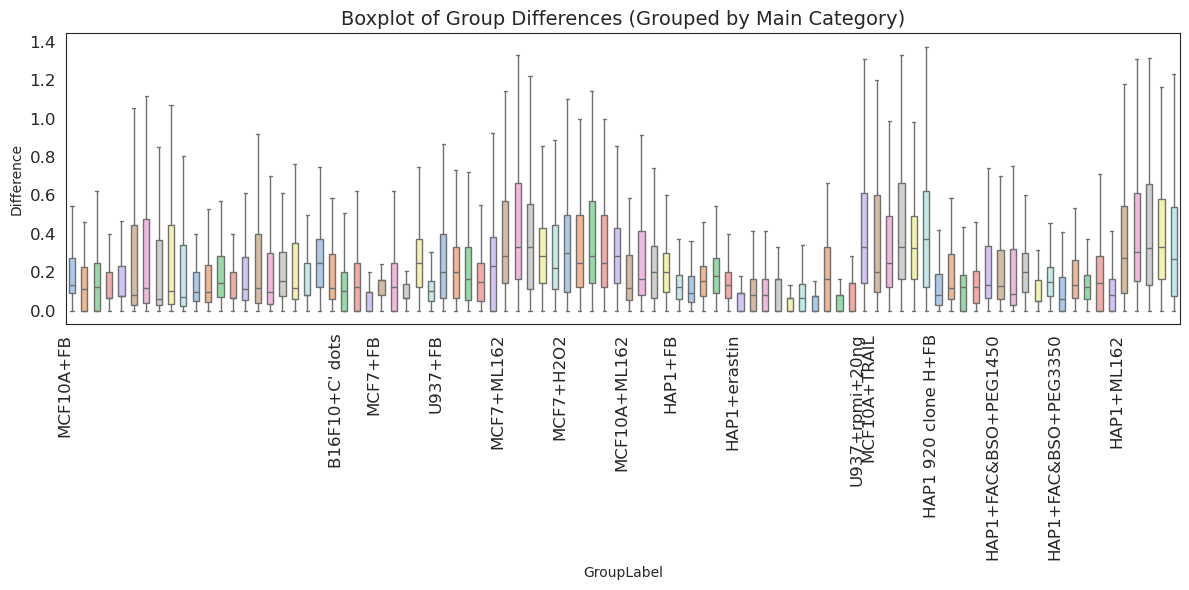

In [6]:
# Sort groups hierarchically
df['MainGroup'] = df['Group'].apply(lambda x: x.split('/')[0])
df['SubGroup'] = df['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df['GroupLabel'] = df['MainGroup'] + ':\n' + df['SubGroup']

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white") 
ax = sns.boxplot(x='GroupLabel', y='Difference', data=df,
                 width=0.5, palette='pastel', showfliers=False)

# Replace subgroup labels with main group labels only once per group
group_labels = df['GroupLabel'].unique()
main_groups = [label.split(':\n')[0] for label in group_labels]

# Build condensed label list where each main group appears only at first index
x_labels = []
seen = set()
for g in main_groups:
    if g not in seen:
        x_labels.append(g)
        seen.add(g)
    else:
        x_labels.append("")

# Apply the new tick labels
ax.set_xticklabels(x_labels, fontsize=12, rotation=90, ha='right')

# Continue formatting
plt.yticks(fontsize=12)
plt.title('Boxplot of Group Differences (Grouped by Main Category)', fontsize=14)
plt.ylabel('Difference')
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical.svg", format="svg", dpi=300)
plt.show()


## Recent Data

In [ ]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_live_only/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_live_only.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(len(exp_names)):
    # if not all(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["DeathMode"] == 'Apoptosis'):
    #     continue
    if 'nec' in exp_names[idx] or 'apop' in exp_names[idx] or 'out' in exp_names[idx] or 'skt' in exp_names[idx].lower():# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
        continue
    # if 'pure' not in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
    #     continue
    print(exp_names[idx])
    exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100 # microns
    cells_location = csv_file[["cell_x","cell_y"]].values
    di_times = csv_file[['death_time']].values
    death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else []
    de_qu = DeathQuanta(cells_xy=cells_location,
                        death_times=di_times, 
                        death_modes=death_modes,
                        dist_threshold=dist_threshold,
                        normalize = True,
                        # n_type = 'median_and_iqr',
                        filter_neighbors_by_distance=True,
                        neighbors_level=1,
                        pure_type = meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Mode"].values[0])
    tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
    group_data[meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["Origin"].values[0]] = tod_pairs_1 # tod_pairs_1.get('apoptosis', []) + tod_pairs_1.get('necrosis', []) if isinstance(tod_pairs_1, dict) else tod_pairs_1

In [12]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(len(exp_names)):
    # if not all(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["DeathMode"] == 'Apoptosis'):
    #     continue
    if 'nec' in exp_names[idx] or 'apop' in exp_names[idx] or 'out' in exp_names[idx] or 'skt' in exp_names[idx].lower() or 'puredeath3' in exp_names[idx] or 'field3' in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
        continue
    # if 'pure' not in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
    #     continue
    print(exp_names[idx])
    exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100 # microns
    cells_location = csv_file[["cell_x","cell_y"]].values
    di_times = csv_file[['death_time']].values
    death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else None
    de_qu = DeathQuanta(cells_xy=cells_location,
                        death_times=di_times, 
                        death_modes=death_modes,
                        dist_threshold=dist_threshold,
                        normalize = True,
                        n_type = 'min_max',
                        filter_neighbors_by_distance=True,
                        neighbors_level=1,
                        pure_type = "necrosis" if "nec" in exp_names[idx] else "apoptosis")
    tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
    group_data[meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["Origin"].values[0]] = tod_pairs_1 # tod_pairs_1.get('apoptosis', []) + tod_pairs_1.get('necrosis', []) if isinstance(tod_pairs_1, dict) else tod_pairs_1

field13_crop-001_ROI#1_annotation_mixed.csv
Field14-002_ROI#1_annotation_mixed.csv
7-20-23_10arednuclei_ROI#10_annotation_mixed.csv
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv
purecolony3_sytox_based.csv
purecolony_sytox_based.csv
purecolony2_sytox_based.csv
mixcolony1.csv
mixcolony2_field13.csv
mixcolony3.csv
3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath1_sytox_based.csv
3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath2_sytox_based.csv


In [44]:
group_data.keys()

dict_keys(['field13_colony', 'field14_colony', 'field11_colony', 'field14_two_colony', 'pure_colony_3', 'pure_colony_1', 'pure_colony_2', 'mix_colony_1', 'mix_colony_2', 'mix_colony_3', 'pure_death_1', 'pure_death_2'])

/tmp/ipykernel_3794922/2332036378.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GroupLabel', y='Difference', data=df,


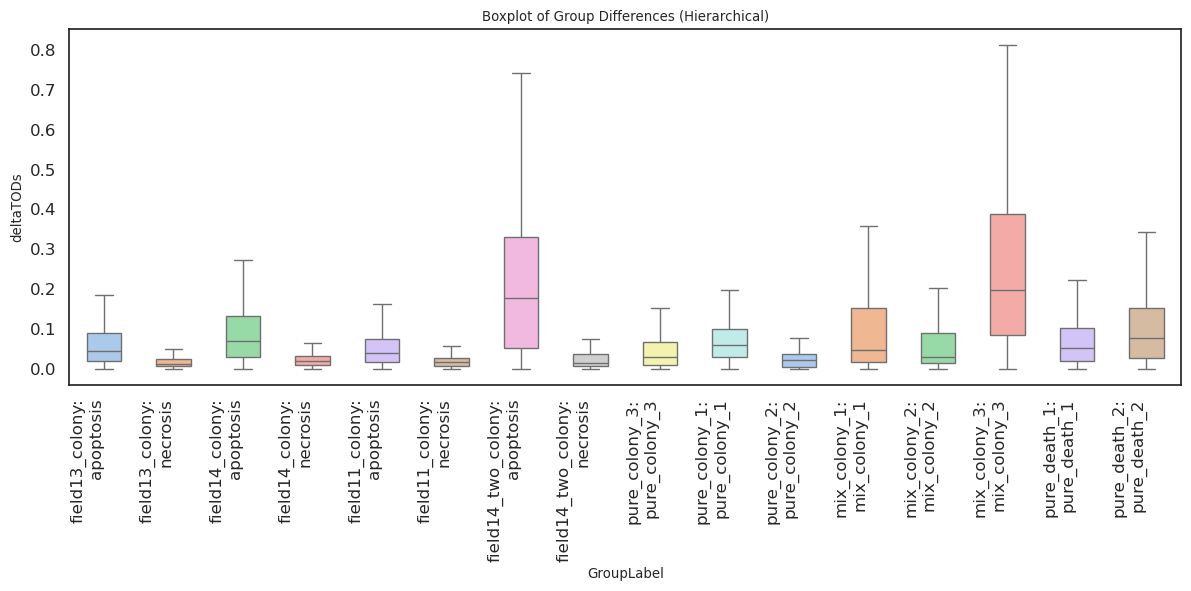

/tmp/ipykernel_3794922/2332036378.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MainGroup', y='Difference', data=df,


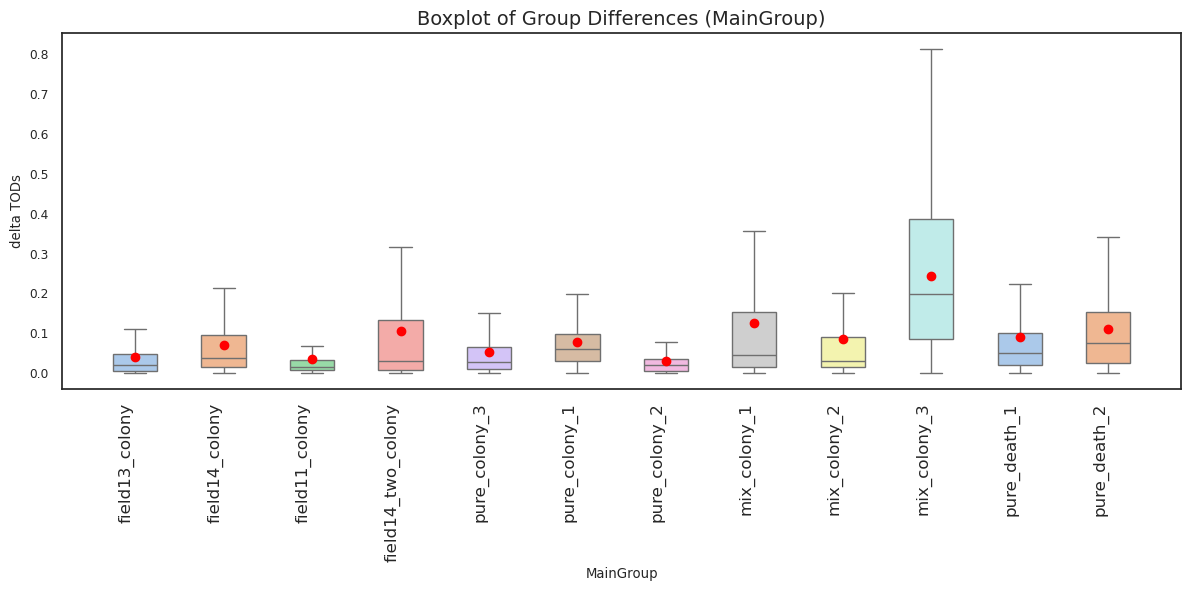

In [13]:
flattened_data = {'Group': [], 'Difference': []}
# Remove "entosis" from group_data
filtered_group_data = {}
for group_name, subgroups in group_data.items():
    if isinstance(subgroups, dict):  # Check if subgroups exist
        filtered_subgroups = {subgroup_name: arrays for subgroup_name, arrays in subgroups.items() if subgroup_name != "entosis"}
        if filtered_subgroups:  # Add only if there are remaining subgroups
            filtered_group_data[group_name] = filtered_subgroups
    else:
        filtered_group_data[group_name] = subgroups  # Keep flat structure unchanged

group_data = filtered_group_data

for group_name, value in group_data.items():
    if isinstance(value, dict):  # Nested: group → subgroup → arrays
        for subgroup_name, arrays in value.items():
            label = f"{group_name}/{subgroup_name}"
            for arr in arrays:
                flattened_data['Group'].extend([label] * len(arr))
                flattened_data['Difference'].extend(arr)
    else:  # Flat list of arrays
        for arr in value:
            flattened_data['Group'].extend([group_name] * len(arr))
            flattened_data['Difference'].extend(arr)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(flattened_data)

# Sort groups hierarchically
df['MainGroup'] = df['Group'].apply(lambda x: x.split('/')[0])
df['SubGroup'] = df['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df['GroupLabel'] = df['MainGroup'] + ':\n' + df['SubGroup']  # for axis formatting

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white") 
sns.boxplot(x='GroupLabel', y='Difference', data=df,
            width=0.5, palette='pastel', showfliers=False)

# Annotate quartiles
for i, label in enumerate(df['GroupLabel'].unique()):
    values = df[df['GroupLabel'] == label]['Difference']
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    # Annotate: uncomment if needed
    # plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    # plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    # plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')
plt.xticks(fontsize=12, rotation=90, ha='right',ticks=range(len(df['GroupLabel'].unique())))
plt.yticks(fontsize=12)
# Format plot
# plt.xticks(rotation=90, ha='right')
plt.title('Boxplot of Group Differences (Hierarchical)')
plt.ylabel('deltaTODs')
plt.grid(False)#, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical.svg", format="svg", dpi=300)
plt.show()
# Save the plot as a high-resolution image suitable for Adobe Illustrator
# Boxplot based on MainGroup
plt.figure(figsize=(12, 6))
sns.set_style("white") 
sns.boxplot(x='MainGroup', y='Difference', data=df,
            width=0.5, palette='pastel', showfliers=False)
# Annotate the mean for each group
for i, group in enumerate(df['MainGroup'].unique()):
    group_values = df[df['MainGroup'] == group]['Difference']
    mean = np.mean(group_values)
    plt.scatter(i, mean, color='red', marker='o', label='Mean' if i == 0 else "", zorder=3)

plt.title('Boxplot of Group Differences (MainGroup)', fontsize=14)
plt.ylabel('delta TODs')
plt.xlabel('MainGroup')
plt.xticks(fontsize=12, rotation=90, ha='right')
plt.tight_layout()
plt.show()


/tmp/ipykernel_3794922/2537017733.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MainGroup', y='Difference', data=df, palette='pastel', showfliers=False)


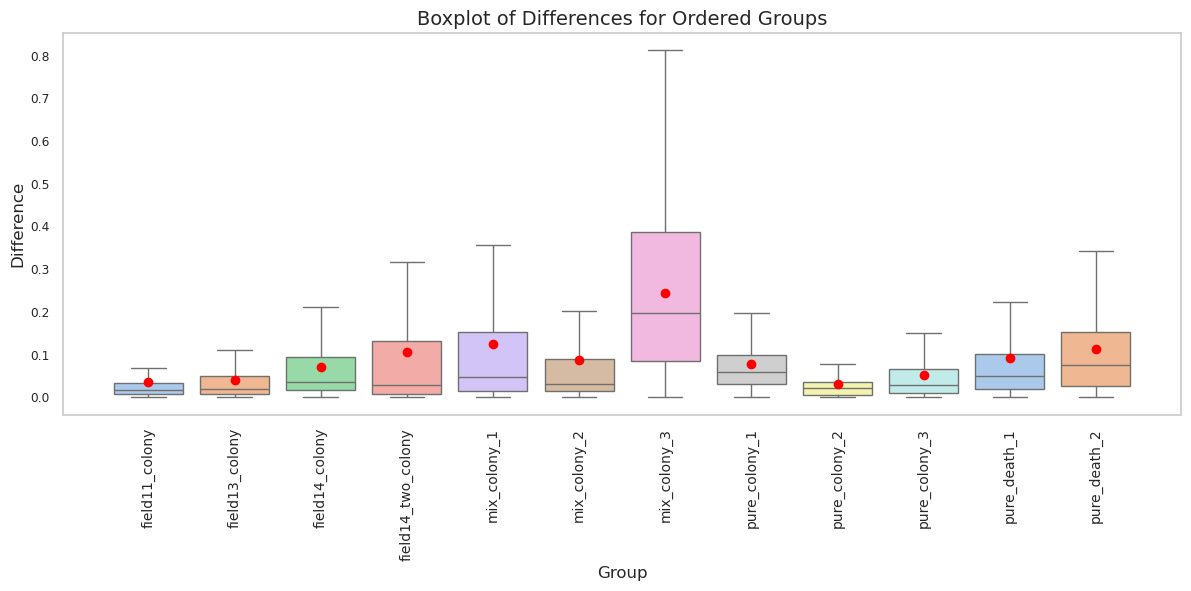

In [14]:
# Define the custom sorting function
def custom_sort_key(group_name):
    if "field" in group_name.lower():
        return (0, group_name.lower())  # Field groups first
    elif "mix" in group_name.lower():
        return (1, group_name.lower())  # Mix groups second
    elif "pure" in group_name.lower():
        return (2, group_name.lower())  # Pure groups last
    else:
        return (3, group_name.lower())  # Other groups

# Apply the sorting to the group names
ordered_group_names = sorted(df['MainGroup'].unique(), key=custom_sort_key)

# Update the DataFrame to use the ordered categories
df['MainGroup'] = pd.Categorical(df['MainGroup'], categories=ordered_group_names, ordered=True)

# Plot the boxplot with the ordered groups
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.boxplot(x='MainGroup', y='Difference', data=df, palette='pastel', showfliers=False)
# Annotate the mean for each group
for i, group in enumerate(ordered_group_names):
    group_values = df[df['MainGroup'] == group]['Difference']
    mean = np.mean(group_values)
    plt.scatter(i, mean, color='red', marker='o', label='Mean' if i == 0 else "", zorder=3)

# Format the plot
plt.title('Boxplot of Differences for Ordered Groups', fontsize=14)
plt.ylabel('Difference', fontsize=12)
plt.xlabel('Group', fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.grid(False)
plt.tight_layout()
plt.show()



In [18]:
filtered_df = df.copy()

In [15]:

# Filter out groups with "mixed" in their Group or MainGroup
filtered_df = df[~df['Group'].str.contains('nec', case=False) & ~df['MainGroup'].str.contains('field3', case=False ) & ~df['SubGroup'].str.contains('apop', case=False)]

# Display the filtered DataFrame
print(filtered_df)

               Group  Difference      MainGroup       SubGroup  \
9286   pure_colony_3    0.292453  pure_colony_3  pure_colony_3   
9287   pure_colony_3    0.226415  pure_colony_3  pure_colony_3   
9288   pure_colony_3    0.283019  pure_colony_3  pure_colony_3   
9289   pure_colony_3    0.745283  pure_colony_3  pure_colony_3   
9290   pure_colony_3    0.264151  pure_colony_3  pure_colony_3   
...              ...         ...            ...            ...   
40661   pure_death_2    0.797468   pure_death_2   pure_death_2   
40662   pure_death_2    0.708861   pure_death_2   pure_death_2   
40663   pure_death_2    0.417722   pure_death_2   pure_death_2   
40664   pure_death_2    0.544304   pure_death_2   pure_death_2   
40665   pure_death_2    0.772152   pure_death_2   pure_death_2   

                          GroupLabel  
9286   pure_colony_3:\npure_colony_3  
9287   pure_colony_3:\npure_colony_3  
9288   pure_colony_3:\npure_colony_3  
9289   pure_colony_3:\npure_colony_3  
9290   pure_

/tmp/ipykernel_935511/672842238.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GroupLabel', y='Difference', data=df,


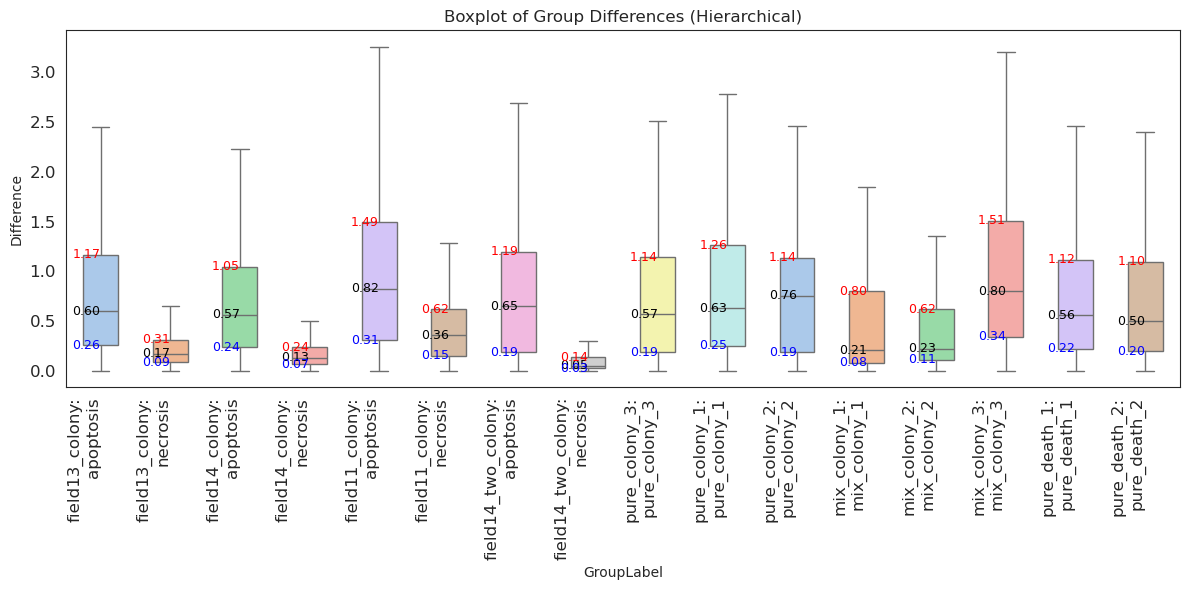

In [22]:
flattened_data = {'Group': [], 'Difference': []}
# Remove "entosis" from group_data
filtered_group_data = {}
for group_name, subgroups in group_data.items():
    if isinstance(subgroups, dict):  # Check if subgroups exist
        filtered_subgroups = {subgroup_name: arrays for subgroup_name, arrays in subgroups.items() if subgroup_name != "entosis"}
        if filtered_subgroups:  # Add only if there are remaining subgroups
            filtered_group_data[group_name] = filtered_subgroups
    else:
        filtered_group_data[group_name] = subgroups  # Keep flat structure unchanged

group_data = filtered_group_data

for group_name, value in group_data.items():
    if isinstance(value, dict):  # Nested: group → subgroup → arrays
        for subgroup_name, arrays in value.items():
            label = f"{group_name}/{subgroup_name}"
            for arr in arrays:
                flattened_data['Group'].extend([label] * len(arr))
                flattened_data['Difference'].extend(arr)
    else:  # Flat list of arrays
        for arr in value:
            flattened_data['Group'].extend([group_name] * len(arr))
            flattened_data['Difference'].extend(arr)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(flattened_data)

# Sort groups hierarchically
df['MainGroup'] = df['Group'].apply(lambda x: x.split('/')[0])
df['SubGroup'] = df['Group'].apply(lambda x: x.split('/')[1] if '/' in x else x)
df['GroupLabel'] = df['MainGroup'] + ':\n' + df['SubGroup']  # for axis formatting

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.set_style("white") 
sns.boxplot(x='GroupLabel', y='Difference', data=df,
            width=0.5, palette='pastel', showfliers=False)

# Annotate quartiles
for i, label in enumerate(df['GroupLabel'].unique()):
    values = df[df['GroupLabel'] == label]['Difference']
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)

    # Annotate: uncomment if needed
    plt.text(i, median, f'{median:.2f}', va='center', ha='right', fontsize=9, color='black')
    plt.text(i, q1, f'{q1:.2f}', va='center', ha='right', fontsize=9, color='blue')
    plt.text(i, q3, f'{q3:.2f}', va='center', ha='right', fontsize=9, color='red')
plt.xticks(fontsize=12, rotation=90, ha='right',ticks=range(len(df['GroupLabel'].unique())))
plt.yticks(fontsize=12)
# Format plot
# plt.xticks(rotation=90, ha='right')
plt.title('Boxplot of Group Differences (Hierarchical)')
plt.ylabel('Difference')
plt.grid(False)#, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/boxplot_hierarchical.svg", format="svg", dpi=300)
plt.show()
# Save the plot as a high-resolution image suitable for Adobe Illustrator



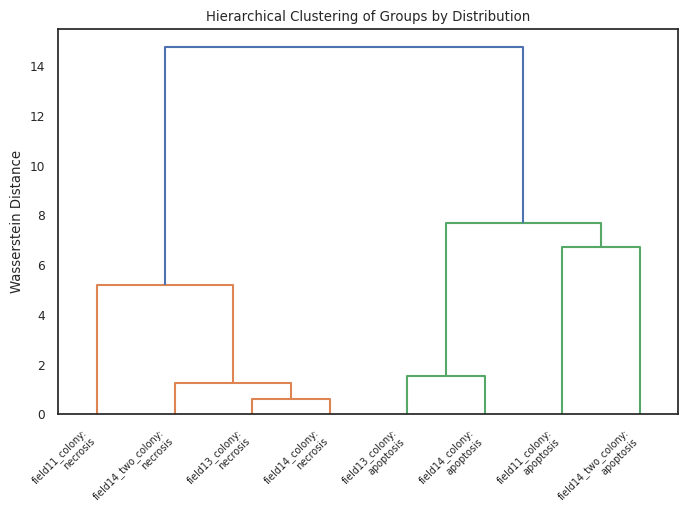

In [37]:
import numpy as np
import scipy.stats as stats
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Example input: dict of group_name -> list of values
# 1. Compute pairwise Wasserstein distances
group_names = filtered_df['GroupLabel'].unique()
n = len(group_names)
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        group_i_values = filtered_df[filtered_df['GroupLabel'] == group_names[i]]['Difference'].values
        group_j_values = filtered_df[filtered_df['GroupLabel'] == group_names[j]]['Difference'].values
        dist = stats.energy_distance(group_i_values, group_j_values)
        dist_matrix[i, j] = dist_matrix[j, i] = dist

# 2. Hierarchical clustering
linkage_matrix = linkage(squareform(dist_matrix), method='complete')
# 3. Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linkage_matrix, labels=group_names)
plt.title('Hierarchical Clustering of Groups by Distribution')
plt.ylabel('Wasserstein Distance')
# Set x-axis labels horizontally
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def extract_features(values):
    return [
        np.mean(values),
        np.std(values),
        stats.skew(values),
        stats.kurtosis(values),
        np.percentile(values, 10),
        np.percentile(values, 50),
        np.percentile(values, 90),
    ]

# Group by 'GroupLabel' and extract features
grouped = filtered_df.groupby('GroupLabel')['Difference']
feature_matrix = np.array([extract_features(values) for _, values in grouped])
group_names = grouped.groups.keys()

# Scale the features
scaled_features = StandardScaler().fit_transform(feature_matrix)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(scaled_features)

# Print the cluster assignments
for name, label in zip(group_names, labels):
    print(f"{name}: Cluster {label}")


field13_colony:
apoptosis: Cluster 0
field13_colony:
necrosis: Cluster 1
field14_colony:
apoptosis: Cluster 0
field14_colony:
necrosis: Cluster 1
field14_two_colony:
apoptosis: Cluster 0
field14_two_colony:
necrosis: Cluster 1
pure_colony_1:
pure_colony_1: Cluster 0
pure_colony_2:
pure_colony_2: Cluster 0
pure_colony_3:
pure_colony_3: Cluster 0
pure_death_1:
pure_death_1: Cluster 0
pure_death_2:
pure_death_2: Cluster 0
pure_death_3:
pure_death_3: Cluster 0


In [24]:
from scipy.stats import wasserstein_distance, energy_distance
import numpy as np
import scipy.stats as stats
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
def compute_distance_matrix(filtered_df, method='energy' , column='MainGroup'):
    group_names = filtered_df[column].unique()
    n = len(group_names)
    dist_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i + 1, n):
            group_i_values = filtered_df[filtered_df[column] == group_names[i]]['Difference'].values
            group_j_values = filtered_df[filtered_df[column] == group_names[j]]['Difference'].values
            if method == 'wasserstein':
                d = wasserstein_distance(group_i_values, group_j_values)
            elif method == 'energy':
                d = energy_distance(group_i_values, group_j_values)
            elif method == 'ks_2samp':
                d, val = stats.ks_2samp(group_i_values, group_j_values)
                print(f"KS Statistic: {val}")
            dist_matrix[i, j] = dist_matrix[j, i] = d
    return dist_matrix, group_names


In [19]:
filtered_df

,Group,Difference,MainGroup,SubGroup,GroupLabel
0,field13_colony/apoptosis,0.158228,field13_colony,apoptosis,field13_colony:\napoptosis
1,field13_colony/apoptosis,0.158228,field13_colony,apoptosis,field13_colony:\napoptosis
2,field13_colony/apoptosis,0.424051,field13_colony,apoptosis,field13_colony:\napoptosis
3,field13_colony/apoptosis,0.360759,field13_colony,apoptosis,field13_colony:\napoptosis
4,field13_colony/apoptosis,0.101266,field13_colony,apoptosis,field13_colony:\napoptosis
...,...,...,...,...,...
40661,pure_death_2,0.797468,pure_death_2,pure_death_2,pure_death_2:\npure_death_2
40662,pure_death_2,0.708861,pure_death_2,pure_death_2,pure_death_2:\npure_death_2
40663,pure_death_2,0.417722,pure_death_2,pure_death_2,pure_death_2:\npure_death_2
40664,pure_death_2,0.544304,pure_death_2,pure_death_2,pure_death_2:\npure_death_2


/tmp/ipykernel_3794922/2527108149.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MainGroup', y='Difference', data=filtered_df, palette='pastel', showfliers=False)


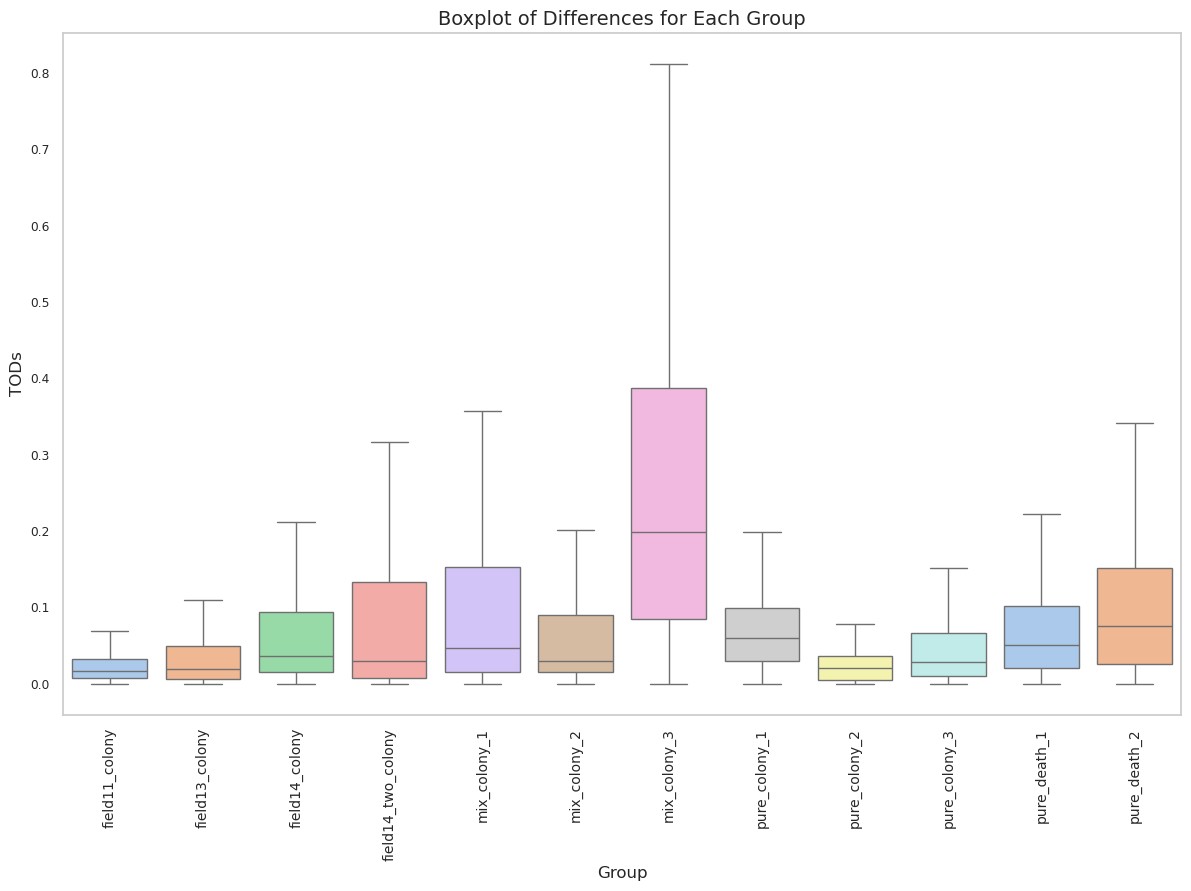

In [22]:
plt.figure(figsize=(12, 9))

ordered_group_names = sorted(filtered_df['MainGroup'].unique(), key=lambda x: ("field" not in x.lower(), "mix" not in x.lower(), x.lower()))
filtered_df['MainGroup'] = pd.Categorical(filtered_df['MainGroup'], categories=ordered_group_names, ordered=True)
sns.set_style("whitegrid")
sns.boxplot(x='MainGroup', y='Difference', data=filtered_df, palette='pastel', showfliers=False)
plt.title('Boxplot of Differences for Each Group', fontsize=14)
plt.ylabel('TODs', fontsize=12)
plt.xlabel('Group', fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.grid(False)
plt.tight_layout()
# Order the group names: "mix" first, then "pure"

plt.show()


KS Statistic: 8.672066907371978e-55
KS Statistic: 1.8388046365955156e-08
KS Statistic: 4.1416840792547315e-49
KS Statistic: 2.7823262305273286e-51
KS Statistic: 1.4022193134152356e-235
KS Statistic: 1.7027989840025354e-20
KS Statistic: 2.937829597435306e-82
KS Statistic: 2.241249206747295e-70
KS Statistic: 6.317306011867153e-292
KS Statistic: 1.061445932728531e-197
KS Statistic: 2.1498559615524437e-255
KS Statistic: 4.824709873287282e-53
KS Statistic: 1.0042925931213267e-23
KS Statistic: 6.4019862865906965e-34
KS Statistic: 2.1329450813278295e-61
KS Statistic: 6.280193688920182e-154
KS Statistic: 5.062698755290498e-19
KS Statistic: 2.347141440771886e-12
KS Statistic: 6.477881524222145e-171
KS Statistic: 7.890606576669538e-45
KS Statistic: 2.0194822013884989e-91
KS Statistic: 2.7972941873823307e-38
KS Statistic: 4.951282884410265e-41
KS Statistic: 9.929278339255086e-141
KS Statistic: 4.321618067485249e-09
KS Statistic: 3.2296930043170744e-74
KS Statistic: 9.934472863956975e-58
KS Statis

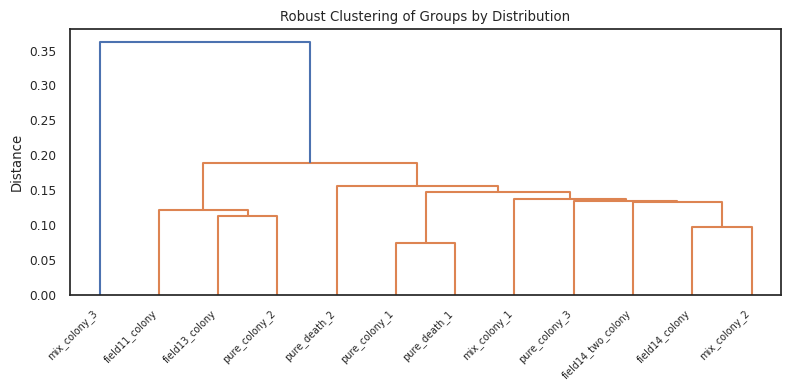

In [26]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

dist_matrix, group_names = compute_distance_matrix(filtered_df, method='ks_2samp', column='MainGroup')
linkage_matrix = linkage(squareform(dist_matrix), method='single')

plt.figure(figsize=(8, 4))

sns.set_style("white")
plt.gcf().set_facecolor('white')
dendrogram(linkage_matrix, labels=group_names)
plt.title('Robust Clustering of Groups by Distribution')
plt.ylabel('Distance')
plt.grid(False)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

# # Set threshold manually or choose number of clusters
# clusters = fcluster(linkage_matrix, t=4, criterion='maxclust')
# for name, c in zip(group_names, clusters):
#     print(f"{name}: Cluster {c}")


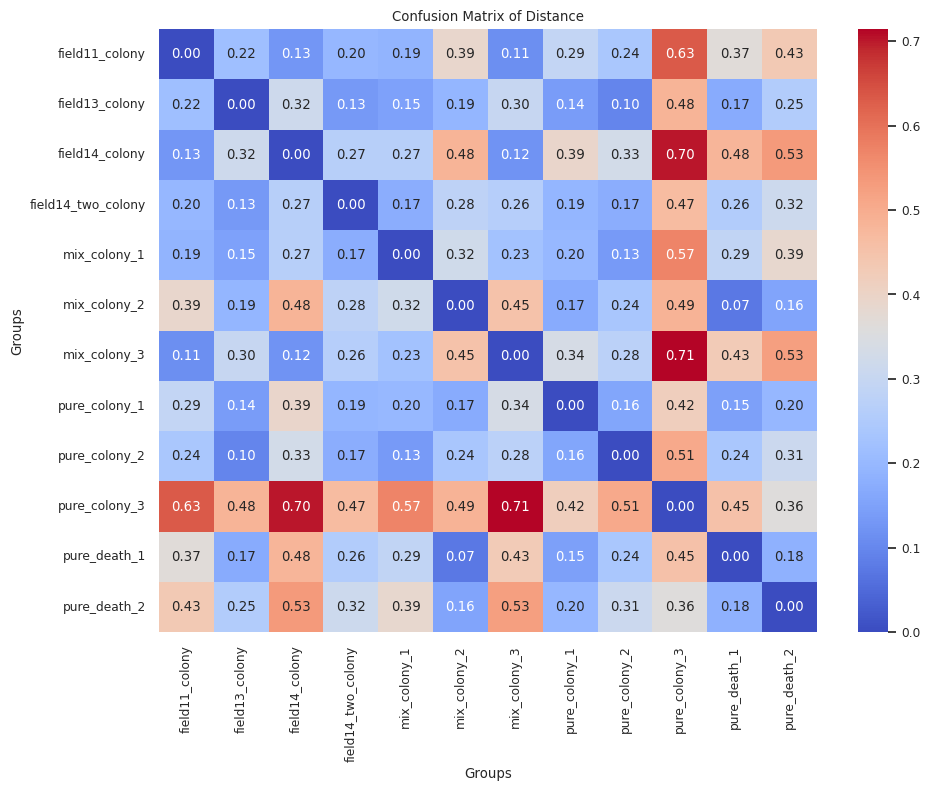

In [27]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Convert dist_matrix to a DataFrame
dist_df = pd.DataFrame(dist_matrix, index=group_names, columns=group_names)
# ordered_group_names = sorted(group_names, key=lambda x: ("nec" not in x.lower(), "apop" not in x.lower(), x.lower()))
# dist_df = dist_df.loc[ordered_group_names, ordered_group_names]
# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.set(font_scale=0.8)
sns.heatmap(dist_df, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=ordered_group_names, yticklabels=ordered_group_names)
# Order the group names: "nec" first, then "apop"

# Format the plot
plt.title("Confusion Matrix of Distance")
plt.xlabel("Groups")
plt.ylabel("Groups")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

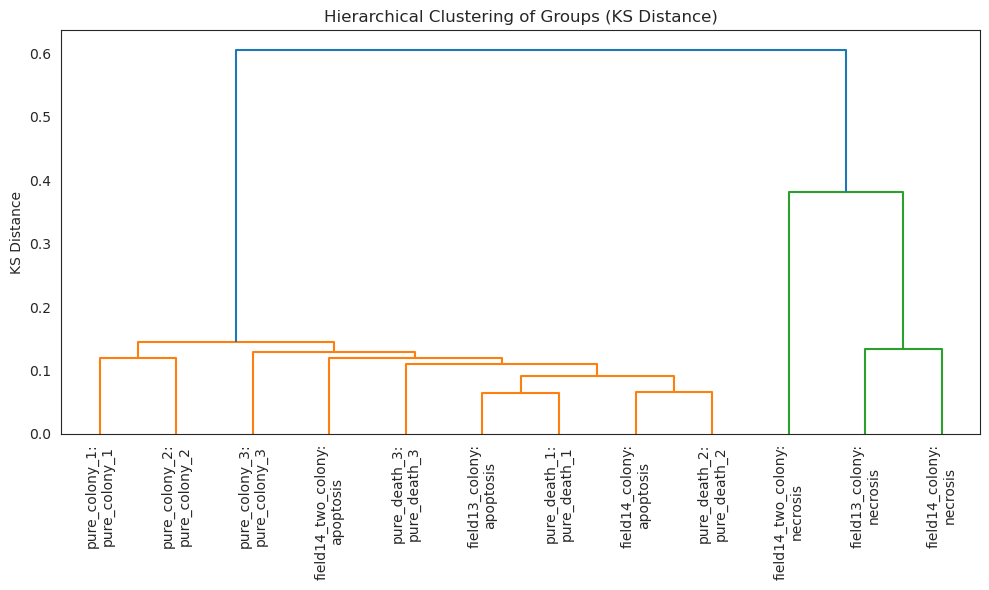

field13_colony:
apoptosis: Cluster 2
field13_colony:
necrosis: Cluster 3
field14_colony:
apoptosis: Cluster 2
field14_colony:
necrosis: Cluster 3
field14_two_colony:
apoptosis: Cluster 2
field14_two_colony:
necrosis: Cluster 4
pure_colony_3:
pure_colony_3: Cluster 2
pure_colony_1:
pure_colony_1: Cluster 1
pure_colony_2:
pure_colony_2: Cluster 1
pure_death_1:
pure_death_1: Cluster 2
pure_death_2:
pure_death_2: Cluster 2
pure_death_3:
pure_death_3: Cluster 2


In [23]:
from scipy.stats import ks_2samp
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

def compute_ks_distance_matrix(filtered_df):
    group_names = filtered_df['GroupLabel'].unique()
    n = len(group_names)
    D_ks = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            group_i_values = filtered_df[filtered_df['GroupLabel'] == group_names[i]]['Difference'].values
            group_j_values = filtered_df[filtered_df['GroupLabel'] == group_names[j]]['Difference'].values
            stat, _ = ks_2samp(group_i_values, group_j_values)
            D_ks[i, j] = D_ks[j, i] = stat

    return D_ks, group_names

# Compute the KS distance matrix
ks_dist_matrix, group_names = compute_ks_distance_matrix(filtered_df)

# Perform hierarchical clustering
linkage_matrix = linkage(squareform(ks_dist_matrix), method='average')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, labels=group_names, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of Groups (KS Distance)')
plt.ylabel('KS Distance')
plt.tight_layout()
plt.show()

# Assign clusters based on a threshold or number of clusters
clusters = fcluster(linkage_matrix, t=4, criterion='maxclust')

# Print the cluster assignments
for name, cluster in zip(group_names, clusters):
    print(f"{name}: Cluster {cluster}")


# Cluster on TOD from nucleuator- no noramlization

In [3]:
# Directory containing the files
dir_files = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'

# Dictionary to store results
death_quanta_results = {}
concatenated_data = {}
dist_threshold = 100  # microns
# Iterate over files in the directory
for file in os.listdir(dir_files):
    if file.endswith('.csv') and 'mix' not in file and "SKT" not in file and "out" not in file  and "ROI#2" not in file and "pure" not in file:# and 'nec' not in file and 'apop' not in file:  # Ensure only CSV files are processed
        file_path = os.path.join(dir_files, file)
        # Read the CSV file
        df = pd.read_csv(file_path)
        # Extract necessary columns
        cells_location = df[["cell_x", "cell_y"]].values
        death_times = df['death_time'].values
        death_modes = df["Mode"].values if "Mode" in df.columns else None
        de_qu = DeathQuanta(
            cells_xy=cells_location,
            death_times=death_times,
            death_modes=death_modes,
            dist_threshold=dist_threshold,

            normalize=True,
            n_type = 'z_score',
            filter_neighbors_by_distance=True,
            filter_neighbors_by_level =True,
            neighbors_level=3,
            pure_type = 'necrosis'
        )
        from_nuc = de_qu.get_TOD_from_nucleator(level=2,)
        # Initialize a dictionary to store concatenated values


        # Concatenate values for all keys in from_nuc
        concatenated_data[file] = [value for key in from_nuc for value in from_nuc[key]]



In [11]:
# Cap values at the 1st and 99th percentiles
df_combined['ClippedValues'] = df_combined.groupby('File')['Values'].transform(
    lambda x: np.clip(x, x.quantile(0.01), x.quantile(0.99))
)
# Group by 'File' and normalize the 'Values' column
df_combined['NormalizedValues'] = df_combined.groupby('File')['ClippedValues'].transform(
    lambda x: (x ) / (x.quantile(0.99) - x.quantile(0.01))
)

# Display the updated DataFrame
print(df_combined)

                                                 File    Values  \
1030  7-20-23_10arednuclei_ROI#10_annotation_apop.csv  0.499002   
1013  7-20-23_10arednuclei_ROI#10_annotation_apop.csv  0.279441   
1014  7-20-23_10arednuclei_ROI#10_annotation_apop.csv  0.309381   
1015  7-20-23_10arednuclei_ROI#10_annotation_apop.csv  0.319361   
1016  7-20-23_10arednuclei_ROI#10_annotation_apop.csv  0.628743   
...                                               ...       ...   
1151        field13_crop-001_ROI#1_annotation_nec.csv  0.106061   
1152        field13_crop-001_ROI#1_annotation_nec.csv  0.075758   
1153        field13_crop-001_ROI#1_annotation_nec.csv  0.166667   
1141        field13_crop-001_ROI#1_annotation_nec.csv  0.257576   
1066        field13_crop-001_ROI#1_annotation_nec.csv  0.106061   

      ClippedValues  NormalizedValues  
1030       0.499002          0.651827  
1013       0.279441          0.365023  
1014       0.309381          0.404132  
1015       0.319361          0.4171

/tmp/ipykernel_712498/3549666362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='File', y='Values', data=df_combined, width=0.5, palette='pastel', showfliers=False)


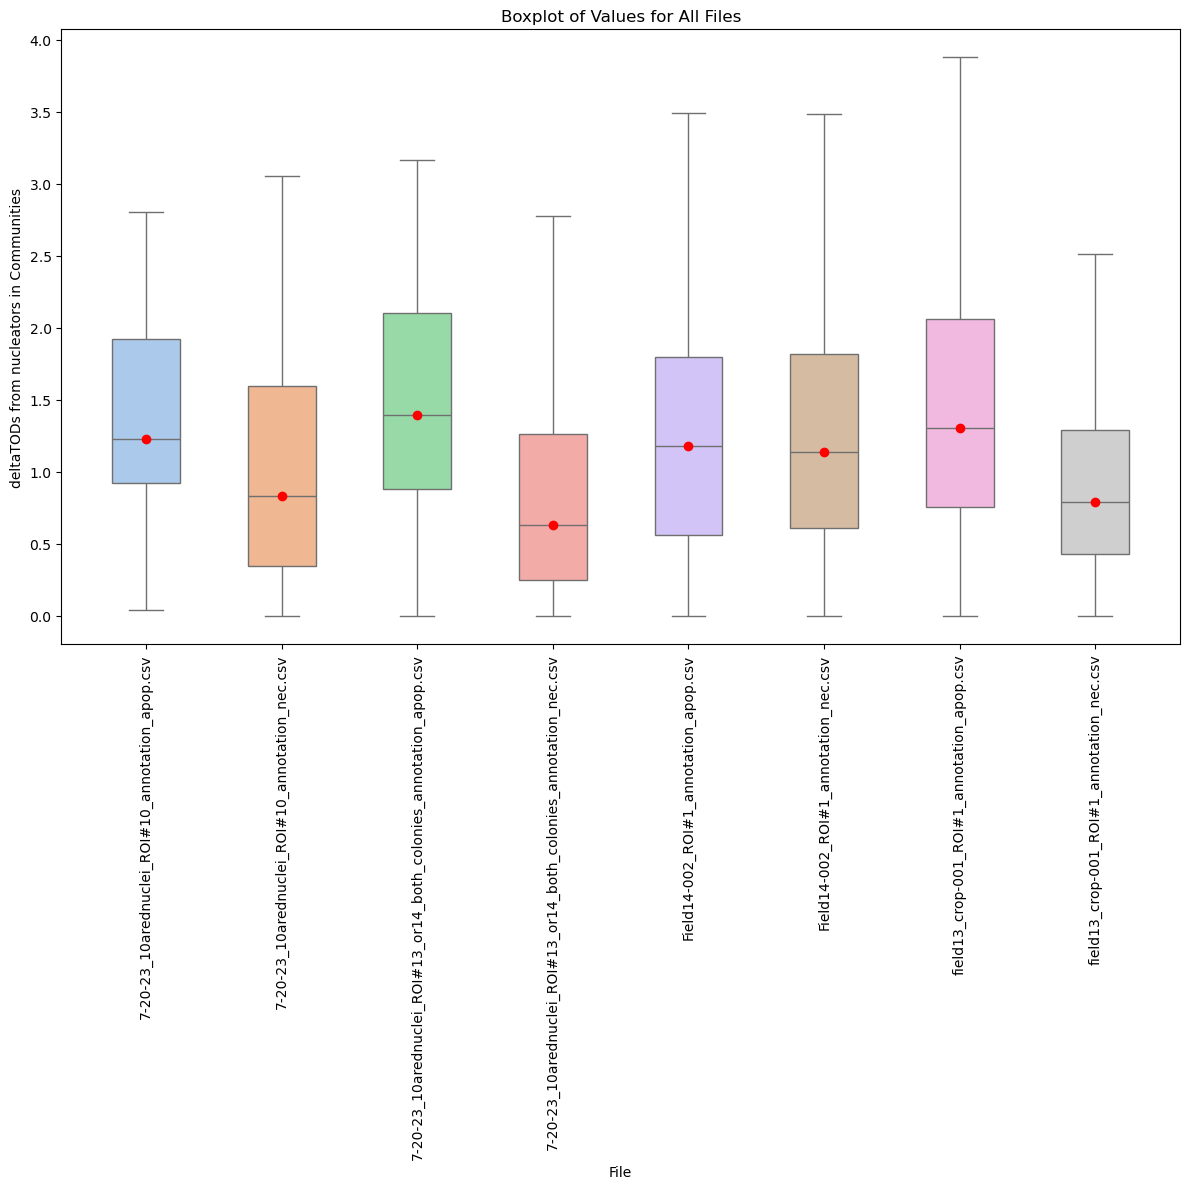

In [5]:
# Plot the boxplot
plt.figure(figsize=(12, 12))
sns.boxplot(x='File', y='Values', data=df_combined, width=0.5, palette='pastel', showfliers=False)

# Annotate median for each file
for i, label in enumerate(df_combined['File'].unique()):
    values = df_combined[df_combined['File'] == label]['Values']
    median = np.median(values)
    plt.scatter(i, median, color='red', marker='o', label='Median' if i == 0 else "", zorder=3)
plt.title('Boxplot of Values for All Files')
plt.xlabel('File')
plt.ylabel('deltaTODs from nucleators in Communities')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

/tmp/ipykernel_712498/2188676299.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='File', y='Values', data=df_combined, width=0.5, palette='pastel', showfliers=False)


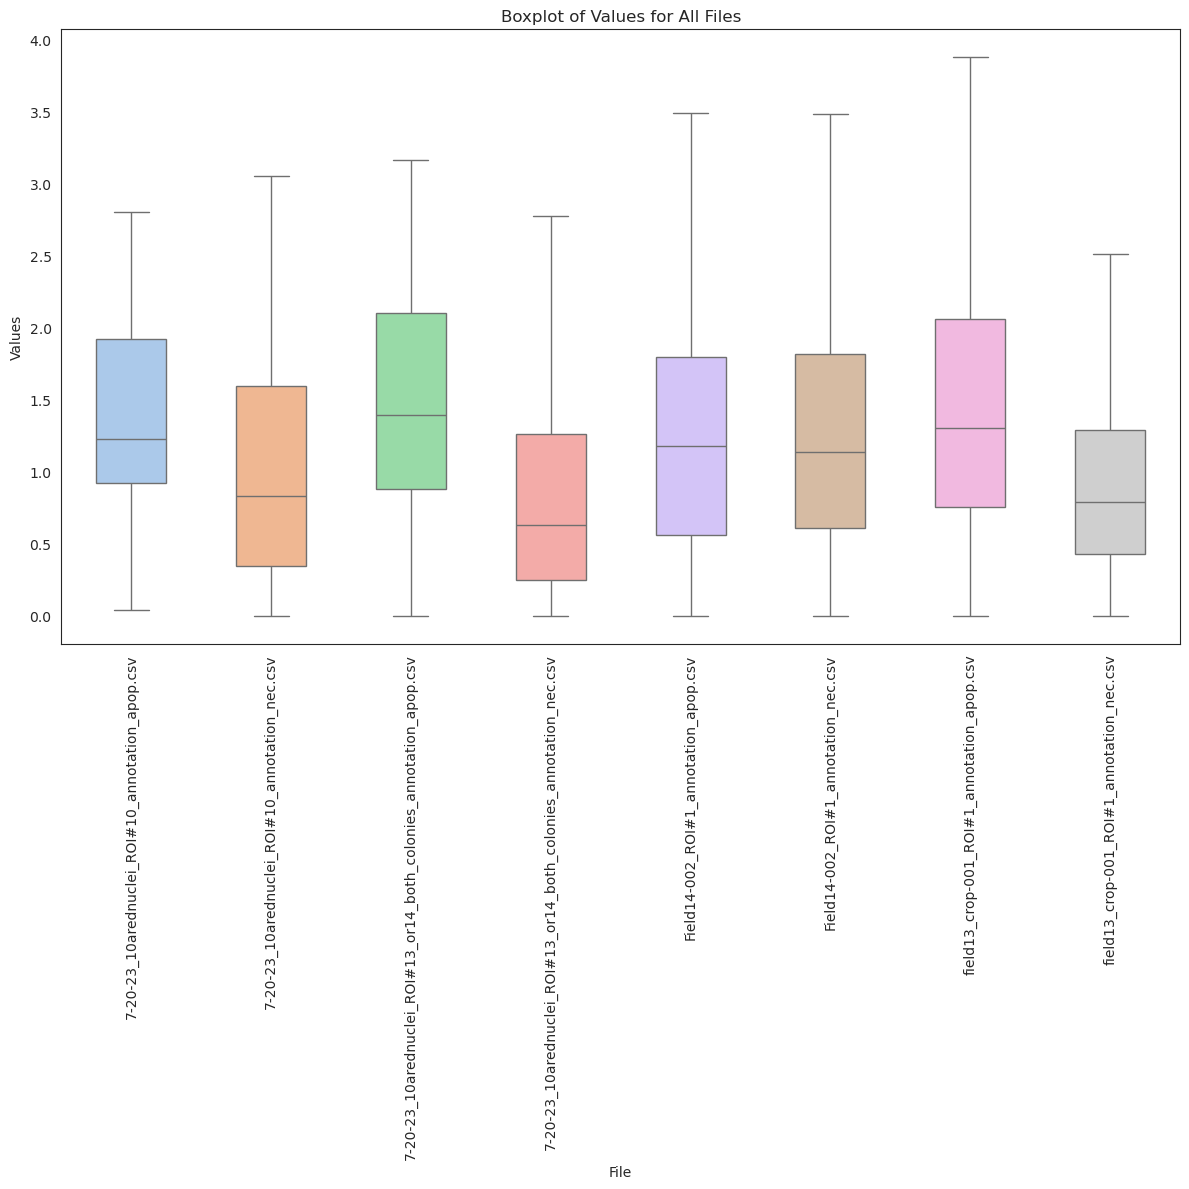

In [11]:
# Combine all data into a single DataFrame
all_data = []
for key, values in concatenated_data.items():
    all_data.extend([(key, value) for value in values])

df_combined = pd.DataFrame(all_data, columns=['File', 'Values'])
df_combined.sort_values(by='File', inplace=True)
# Plot the boxplot
plt.figure(figsize=(12, 12))
sns.boxplot(x='File', y='Values', data=df_combined, width=0.5, palette='pastel', showfliers=False)
plt.title('Boxplot of Values for All Files')
plt.xlabel('File')
plt.ylabel('Values')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## other distances: ks_2sample, energy_distance, wasserstein_distance:

0.0015372077649385006
0.5187142455224576
3.084370281845074e-07
0.09261345519862607
0.06098957723385409
0.44167067308257146
5.047227911983472e-05
9.109327008194458e-07
0.002515424373312062
0.012881096849723257
0.023368698165532026
0.00015355826489671755
0.12823893131569505
2.164016372740767e-18
0.006237068882657993
0.005534814196313467
0.1647413217278866
3.4604467044972584e-15
2.6967378263969864e-11
4.7030559358814e-09
4.533497588676231e-14
0.00015256356305586648
0.9041958754575219
0.20061672414601597
1.116749892775278e-08
0.1496899535837913
2.3230981283670714e-07
5.610757150042974e-11


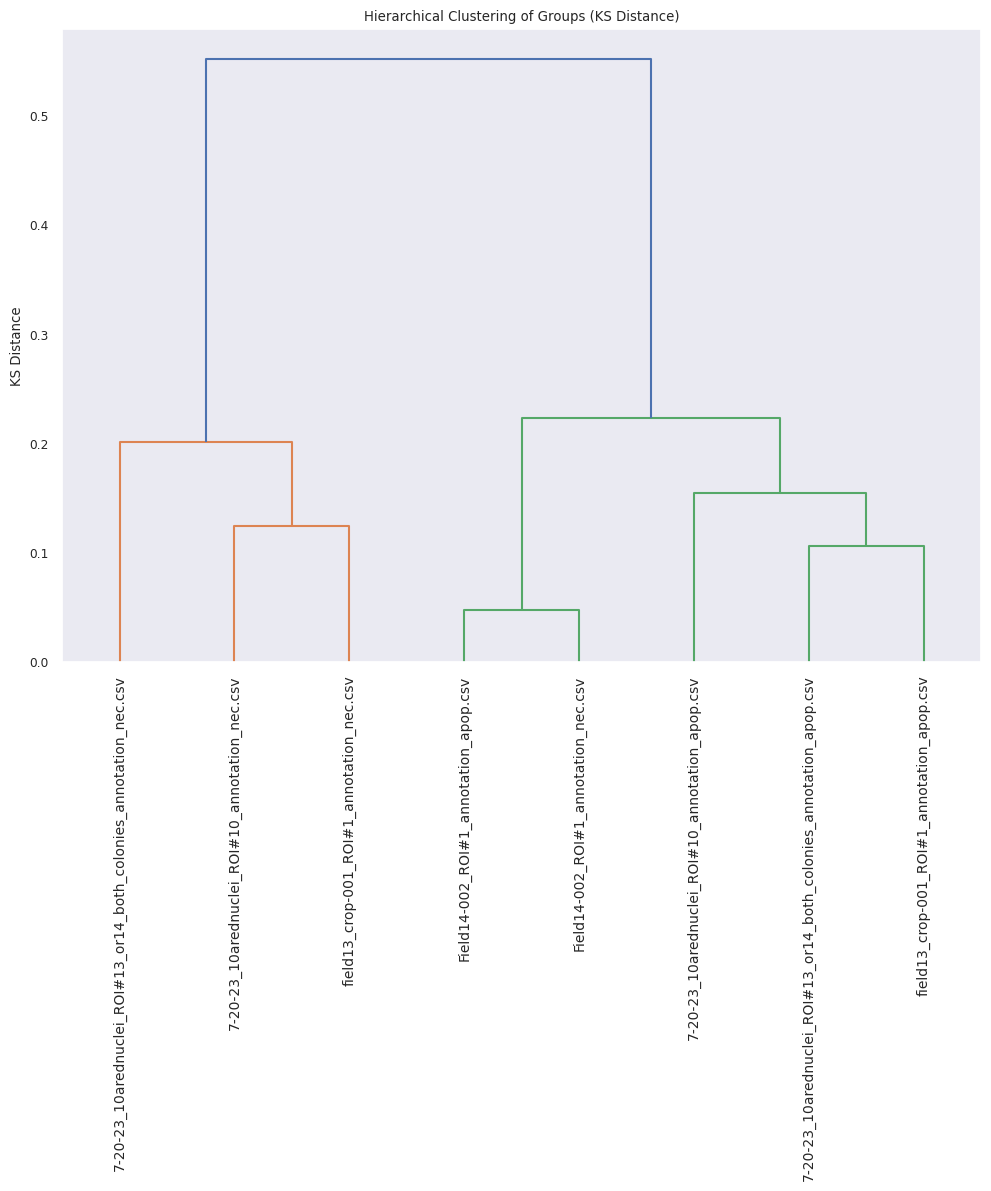

In [17]:
from scipy.stats import ks_2samp
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

def compute_ks_distance_matrix(df_combined, column_name='Values'):
    group_names = df_combined['File'].unique()
    n = len(group_names)
    D_ks = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            group_i_values = df_combined[df_combined['File'] == group_names[i]][column_name].values
            group_j_values = df_combined[df_combined['File'] == group_names[j]][column_name].values
            stat, _ = ks_2samp(group_i_values, group_j_values)
            print(_)
            D_ks[i, j] = D_ks[j, i] = stat

    return D_ks, group_names

# Compute the KS distance matrix
ks_dist_matrix, group_names = compute_ks_distance_matrix(df_combined, column_name='Values')

# Perform hierarchical clustering
linkage_matrix = linkage(squareform(ks_dist_matrix), method='ward')#, metric = 'wasserstein')

# Plot the dendrogram
plt.figure(figsize=(10, 12))
dendrogram(linkage_matrix, labels=group_names, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of Groups (KS Distance)')
plt.ylabel('KS Distance')
plt.grid(False)
plt.tight_layout()
plt.show()

# # Assign clusters based on a threshold or number of clusters
# clusters = fcluster(linkage_matrix, t=4, criterion='maxclust')

# # Print the cluster assignments
# for name, cluster in zip(group_names, clusters):
#     print(f"{name}: Cluster {cluster}")


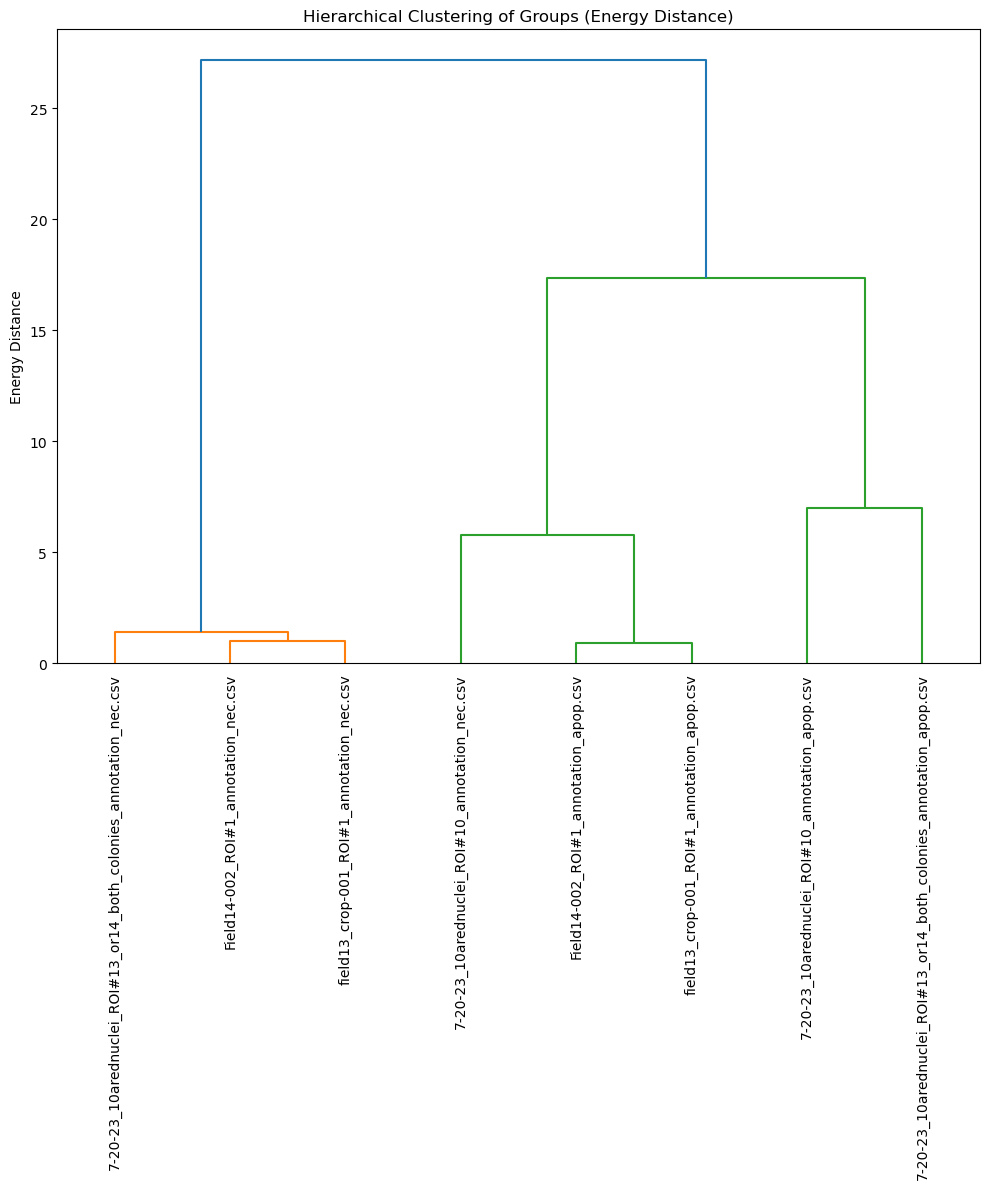

In [25]:
from scipy.stats import energy_distance
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

def compute_energy_distance_matrix(df_combined, column_name='Values'):
    group_names = df_combined['File'].unique()
    n = len(group_names)
    D_energy = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            group_i_values = df_combined[df_combined['File'] == group_names[i]][column_name].values
            group_j_values = df_combined[df_combined['File'] == group_names[j]][column_name].values
            dist = energy_distance(group_i_values, group_j_values)
            D_energy[i, j] = D_energy[j, i] = dist

    return D_energy, group_names

# Compute the energy distance matrix
energy_dist_matrix, group_names = compute_energy_distance_matrix(df_combined, column_name='Values')

# Perform hierarchical clustering
linkage_matrix = linkage(squareform(energy_dist_matrix), method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 12))
dendrogram(linkage_matrix, labels=group_names, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of Groups (Energy Distance)')
plt.ylabel('Energy Distance')
plt.tight_layout()
plt.show()



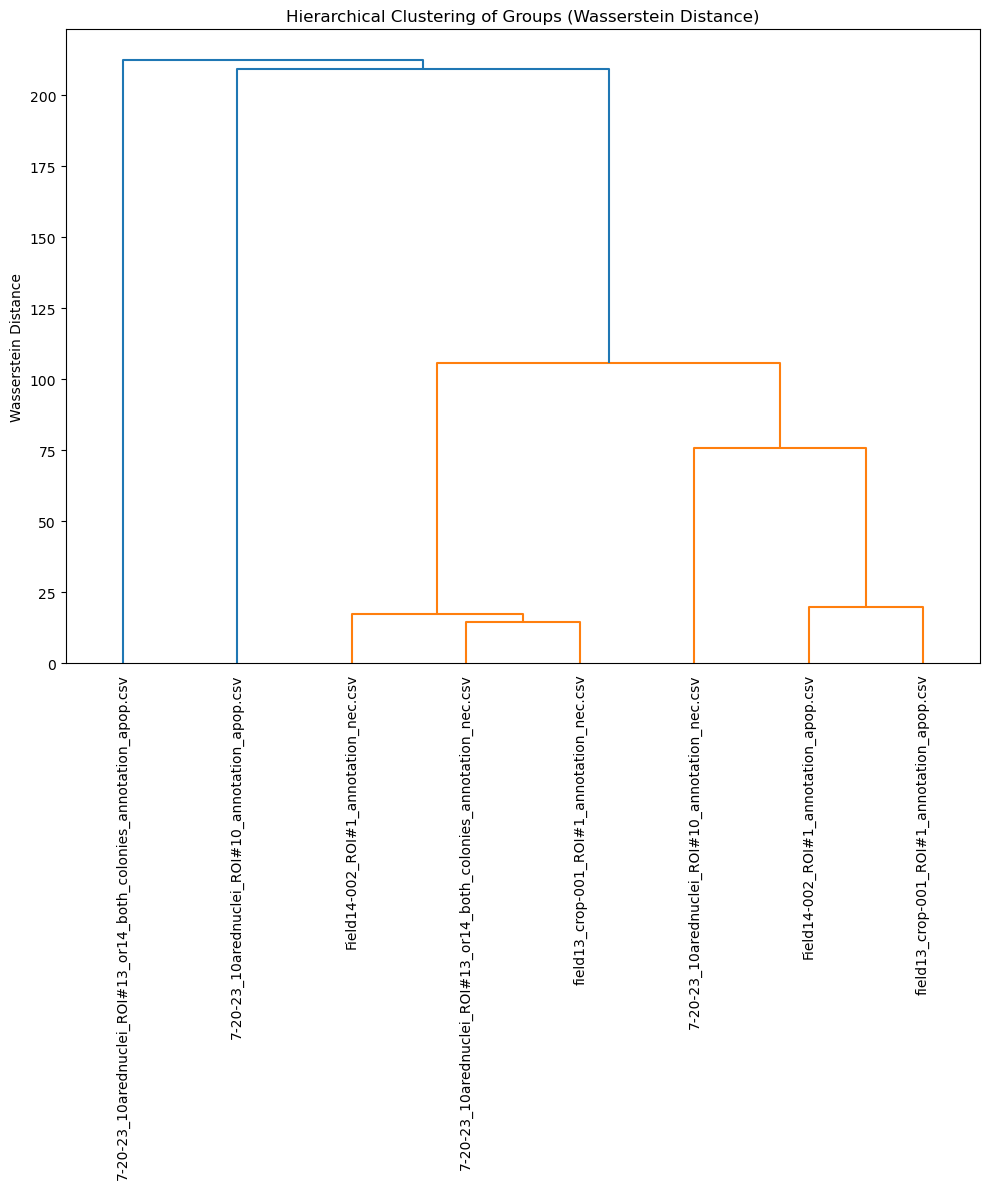

Field14-002_ROI#1_annotation_nec.csv: Cluster 1
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_nec.csv: Cluster 1
7-20-23_10arednuclei_ROI#10_annotation_nec.csv: Cluster 2
Field14-002_ROI#1_annotation_apop.csv: Cluster 2
7-20-23_10arednuclei_ROI#10_annotation_apop.csv: Cluster 3
field13_crop-001_ROI#1_annotation_nec.csv: Cluster 1
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_apop.csv: Cluster 4
field13_crop-001_ROI#1_annotation_apop.csv: Cluster 2


In [26]:
from scipy.stats import wasserstein_distance
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

def compute_wasserstein_distance_matrix(df_combined, column_name='Values'):
    group_names = df_combined['File'].unique()
    n = len(group_names)
    D_wasserstein = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            group_i_values = df_combined[df_combined['File'] == group_names[i]][column_name].values
            group_j_values = df_combined[df_combined['File'] == group_names[j]][column_name].values
            dist = wasserstein_distance(group_i_values, group_j_values)
            D_wasserstein[i, j] = D_wasserstein[j, i] = dist

    return D_wasserstein, group_names

# Compute the Wasserstein distance matrix
wasserstein_dist_matrix, group_names = compute_wasserstein_distance_matrix(df_combined, column_name='Values')

# Perform hierarchical clustering
linkage_matrix = linkage(squareform(wasserstein_dist_matrix), method='single', metric = 'manhattan')

# Plot the dendrogram
plt.figure(figsize=(10, 12))
dendrogram(linkage_matrix, labels=group_names, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of Groups (Wasserstein Distance)')
plt.ylabel('Wasserstein Distance')
plt.tight_layout()
plt.show()

# Assign clusters based on a threshold or number of clusters
clusters = fcluster(linkage_matrix, t=4, criterion='maxclust')

# Print the cluster assignments
for name, cluster in zip(group_names, clusters):
    print(f"{name}: Cluster {cluster}")


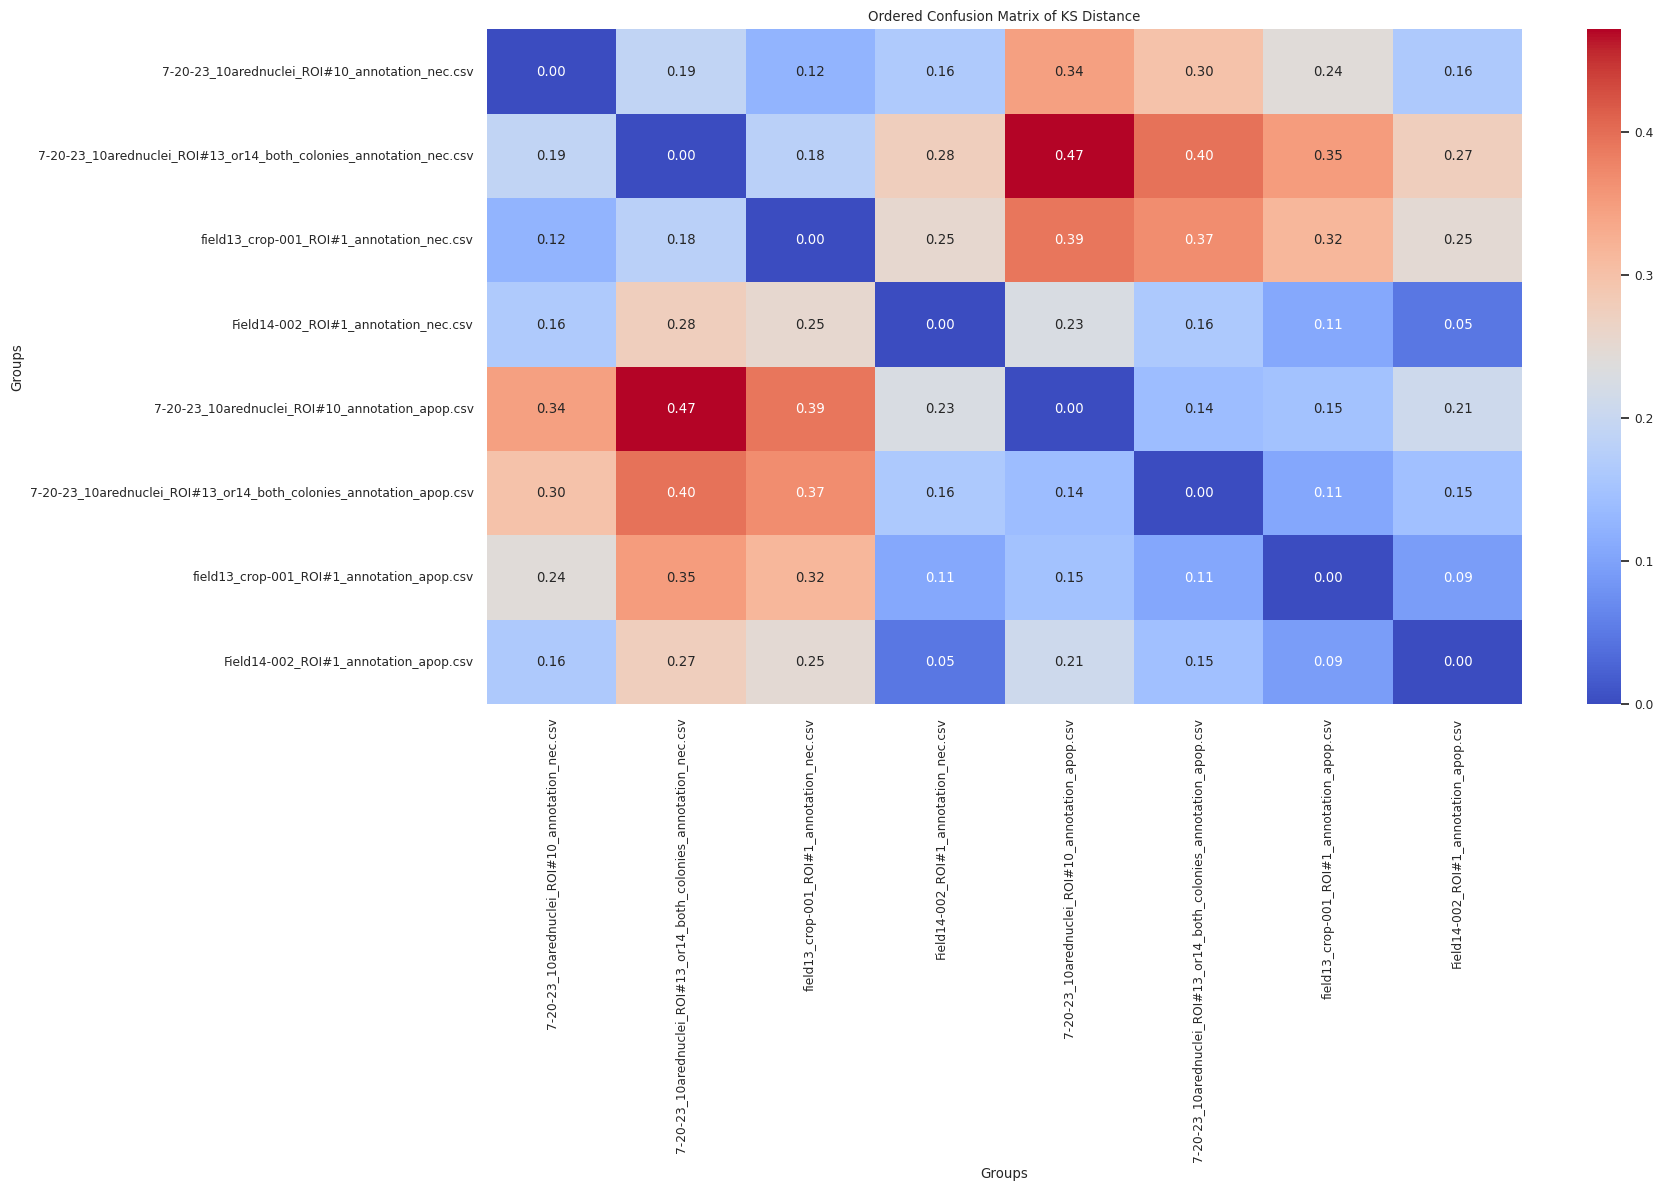

In [18]:

import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Convert ks_dist_matrix to a DataFrame
ks_dist_df = pd.DataFrame(ks_dist_matrix, index=group_names, columns=group_names)

# Order the group names: "nec" first, then "apop"
ordered_group_names = sorted(group_names, key=lambda x: ("pure" not in x.lower(), "nec" not in x.lower(), "apop" not in x.lower(), x.lower()))
ks_dist_df = ks_dist_df.loc[ordered_group_names, ordered_group_names]

# Plot the confusion matrix
plt.figure(figsize=(18,12))
sns.set(font_scale=0.8)
sns.heatmap(ks_dist_df, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=ordered_group_names, yticklabels=ordered_group_names)

# Format the plot
plt.title("Ordered Confusion Matrix of KS Distance")
plt.xlabel("Groups")
plt.ylabel("Groups")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

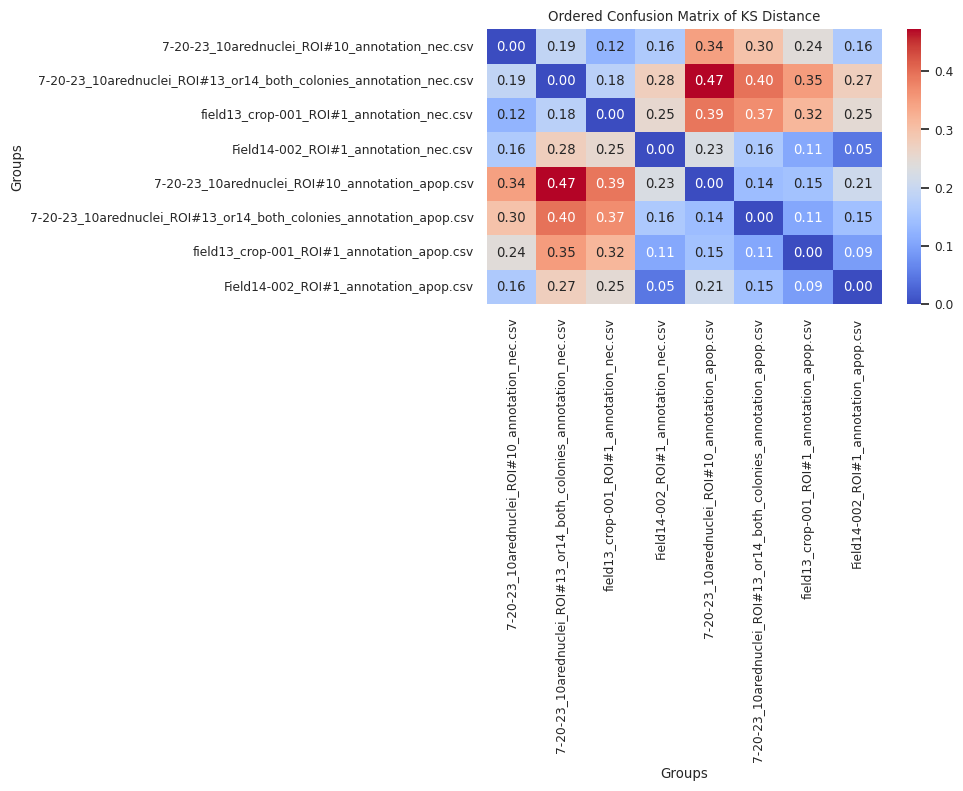

In [13]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Convert ks_dist_matrix to a DataFrame
ks_dist_df = pd.DataFrame(ks_dist_matrix, index=group_names, columns=group_names)

# Order the group names: "nec" first, then "apop"
ordered_group_names = sorted(group_names, key=lambda x: ("pure" not in x.lower(), "nec" not in x.lower(), "apop" not in x.lower(), x.lower()))
ks_dist_df = ks_dist_df.loc[ordered_group_names, ordered_group_names]

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.set(font_scale=0.8)
sns.heatmap(ks_dist_df, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=ordered_group_names, yticklabels=ordered_group_names)

# Format the plot
plt.title("Ordered Confusion Matrix of KS Distance")
plt.xlabel("Groups")
plt.ylabel("Groups")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

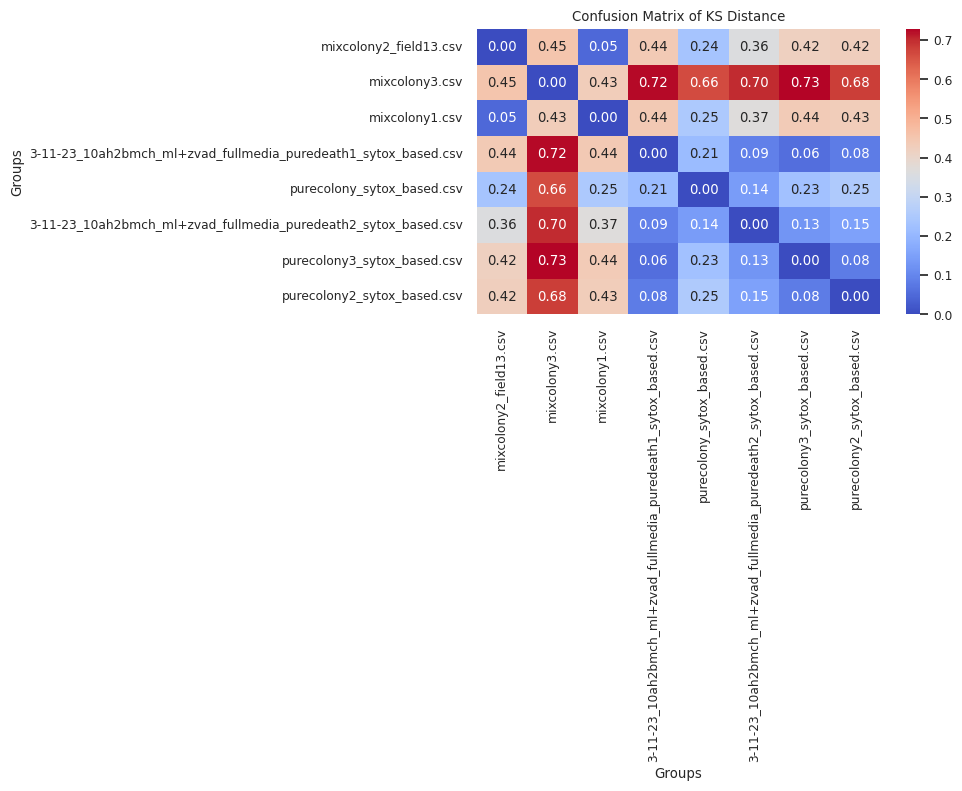

In [11]:
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.set(font_scale=0.8)
sns.heatmap(ks_dist_matrix, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=group_names, yticklabels=group_names)

# Format the plot
plt.title("Confusion Matrix of KS Distance")
plt.xlabel("Groups")
plt.ylabel("Groups")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()